<a href="https://colab.research.google.com/github/Kornieks/E-commerce-Performance/blob/main/Final_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connecting to the dataset and libraries

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import normaltest, spearmanr, f_oneway, pearsonr, shapiro, mannwhitneyu, kruskal


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import plotly.express as px

import matplotlib.cm as cm
import matplotlib.colors as mcolors



auth.authenticate_user()

In [ ]:
client = bigquery.Client(project="data-analytics-mate")


In [ ]:
query = """
WITH order_info AS (SELECT
  ga_session_id,
  p.name,
  p.category,
  p.price,
  p.short_description
FROM `DA.order` AS o
JOIN `DA.product` AS p
ON o.item_id = p.item_id),

account_info AS (SELECT
  acs.ga_session_id,
  a.id,
  a.is_verified,
  a.is_unsubscribed
FROM `DA.account_session` AS acs
JOIN `DA.account` AS a
ON acs.account_id = a.id)



SELECT
  s.date,
  s.ga_session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.name AS channel_info,
  sp.channel,
  ai.id AS customer_id,
  ai.is_verified AS email_is_verified,
  ai.is_unsubscribed AS email_is_unsubscribed,
  oi.category AS product_category,
  oi.name AS product_name,
  oi.price AS product_price,
  oi.short_description AS product_description
FROM `DA.session` AS s
LEFT JOIN `DA.session_params` AS sp
ON sp.ga_session_id = s.ga_session_id
LEFT JOIN account_info AS ai
ON s.ga_session_id = ai.ga_session_id
LEFT JOIN order_info as oi
ON s.ga_session_id = oi.ga_session_id
"""


In [ ]:
query_job = client.query(query)  # Running an SQL-query
results = query_job.result()  # Fetching results
df = results.to_dataframe() # Saving results in a dataframe


In [ ]:
df.to_csv('output_pandas.csv', index=False) # Saving results in csv for Tableau vis

#Data Overview

In [ ]:
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,channel_info,channel,customer_id,email_is_verified,email_is_unsubscribed,product_category,product_name,product_price,product_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   date                   349545 non-null  dbdate 
 1   ga_session_id          349545 non-null  Int64  
 2   continent              349545 non-null  object 
 3   country                349545 non-null  object 
 4   device                 349545 non-null  object 
 5   browser                349545 non-null  object 
 6   mobile_model_name      349545 non-null  object 
 7   operating_system       349545 non-null  object 
 8   language               235279 non-null  object 
 9   channel_info           349545 non-null  object 
 10  channel                349545 non-null  object 
 11  customer_id            27945 non-null   Int64  
 12  email_is_verified      27945 non-null   Int64  
 13  email_is_unsubscribed  27945 non-null   Int64  
 14  product_category       33538 non-nul

In [ ]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'Number of numerical columns: {df.select_dtypes(include='number').shape[1]}')
print(f'Number of categorical columns: {df.select_dtypes(include='object').shape[1]}')
print(f'Number of datetime columns: {df.select_dtypes(include='dbdate').shape[1]}')

print(f'The dataset contains data from {df['date'].min()} to {df['date'].max()}')

print(f'Number of unique sessions: {df['ga_session_id'].nunique()}')


Number of rows: 349545
Number of columns: 18
Number of numerical columns: 5
Number of categorical columns: 12
Number of datetime columns: 1
The dataset contains data from 2020-11-01 to 2021-01-31
Number of unique sessions: 349545


In [ ]:
df.select_dtypes(include="number")

,ga_session_id,customer_id,email_is_verified,email_is_unsubscribed,product_price
0,5760483956,<NA>,<NA>,<NA>,609.0
1,7115337200,<NA>,<NA>,<NA>,609.0
2,3978035233,<NA>,<NA>,<NA>,189.0
3,9648986282,<NA>,<NA>,<NA>,609.0
4,4393441533,<NA>,<NA>,<NA>,609.0
...,...,...,...,...,...
349540,5756982967,<NA>,<NA>,<NA>,NaN
349541,464560636,<NA>,<NA>,<NA>,NaN
349542,6336117447,<NA>,<NA>,<NA>,NaN
349543,4958826563,<NA>,<NA>,<NA>,NaN


In [ ]:
df.select_dtypes(include="object")

,continent,country,device,browser,mobile_model_name,operating_system,language,channel_info,channel,product_category,product_name,product_description
0,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,Bookcases & shelving units,VITTSJÖ,"Shelving unit with laptop table, 202x36x175 cm"
1,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,Bookcases & shelving units,VITTSJÖ,"Shelving unit with laptop table, 202x36x175 cm"
2,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,Tables & desks,RÅSKOG,"Trolley, 35x45x78 cm"
3,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,Bookcases & shelving units,VITTSJÖ,"Shelving unit with laptop table, 202x36x175 cm"
4,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,Bookcases & shelving units,VITTSJÖ,"Shelving unit with laptop table, 202x36x175 cm"
...,...,...,...,...,...,...,...,...,...,...,...,...
349540,Europe,Ukraine,desktop,Firefox,Firefox,Windows,en-us,(referral),Social Search,None,None,None
349541,Americas,United States,desktop,Edge,Edge,Web,en-us,(organic),Organic Search,None,None,None
349542,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(direct),Direct,None,None,None
349543,Asia,India,mobile,Safari,iPhone,iOS,de,(data deleted),Undefined,None,None,None


##Conclusions

The dataset contains information about sessions of a particular online store, including orders from 2020-11-01 to 2021-01-31.
It consists of 349,544 rows and 18 columns (excluding the index).

12 columns contain **categorical data**, including:
continent, country, device, browser, mobile_model_name, operating_system, language, channel_info, channel, product_category, product_name, and product_description.

2 columns are **identifier variables:**
ga_session_id and customer_id (for registered customers).

2 columns contain **boolean data** describing email status:
email_is_verified and email_is_subscribed.

1 column contains **numerical data:**
product_price (USD).

1 column contains date/time information:
dbdate (the date of the session), stored as a datetime variable.


#Data Cleaning

In [ ]:
df.isna().sum()

,0
date,0
ga_session_id,0
continent,0
country,0
device,0
browser,0
mobile_model_name,0
operating_system,0
language,114266
channel_info,0


In [ ]:
# Percentage of missing values
df.isna().sum() * 100 / df.shape[0]

,0
date,0.000000
ga_session_id,0.000000
continent,0.000000
country,0.000000
device,0.000000
browser,0.000000
mobile_model_name,0.000000
operating_system,0.000000
language,32.689925
channel_info,0.000000


In [ ]:
# Look for duplicate values
print(f'Covered continents: {df['continent'].unique()}')
print(f'Device types: {df['device'].unique()}')
print(f'Browser types: {df['browser'].unique()}')
print(f'Mobile model names : {df['mobile_model_name'].unique()}')
print(f'Operating systems : {df['operating_system'].unique()}')
print(f'Operating systems : {df['language'].unique()}')
print(f'Channel : {df['channel'].unique()}')
print(f'Channel info : {df['channel_info'].unique()}')

print(f'\nProduct_category : {df['product_category'].unique()}')

Covered continents: ['Americas' 'Europe' 'Africa' 'Asia' 'Oceania' '(not set)']
Device types: ['desktop' 'mobile' 'tablet']
Browser types: ['Chrome' 'Safari' 'Android Webview' '<Other>' 'Edge' 'Firefox']
Mobile model names : ['Safari' 'Chrome' '<Other>' 'iPhone' 'Pixel 3' 'ChromeBook' 'iPad'
 'Pixel 4 XL' 'Edge' 'Firefox']
Operating systems : ['Macintosh' 'Web' 'Android' 'Windows' 'iOS' '<Other>']
Operating systems : ['zh' 'en-us' 'es-es' None 'en-gb' 'en-ca' 'fr' 'ko' 'en' 'de']
Channel : ['Paid Search' 'Organic Search' 'Direct' 'Undefined' 'Social Search']
Channel info : ['<Other>' '(organic)' '(direct)' '(data deleted)' '(referral)']

Product_category : ['Bookcases & shelving units' 'Tables & desks' 'Cabinets & cupboards'
 'Bar furniture' None 'Chairs' 'Sofas & armchairs' 'Outdoor furniture'
 'Beds' "Children's furniture" 'Chests of drawers & drawer units'
 'Room dividers' 'Sideboards, buffets & console tables' 'Café furniture'
 'Nursery furniture']


In [ ]:
# Check if there are duplicated rows

print(f'The number of duplicated rows: {df.duplicated().sum()}')

# Check if there are hidden duplicates
df_clean = df.copy()
df_clean = df_clean.apply(lambda val:
                          val.str.strip().str.lower()
                          if val.dtype == 'object' else val)

print(f'The number of hidden duplicated rows: {df_clean.duplicated().sum()}')


The number of duplicated rows: 0
The number of hidden duplicated rows: 0


In [ ]:
# Look for anomalities
df['product_price'].describe()

,product_price
count,33538.000000
mean,953.298679
std,1317.001775
min,3.000000
25%,170.000000
50%,445.000000
75%,1195.000000
max,9585.000000


In [ ]:
# Price outlier detection
# IQR
Q1 = df['product_price'].quantile(0.25)
Q3 = df['product_price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['product_price'] < Q1 - 1.5 * IQR) | (df['product_price'] > Q3 + 1.5 * IQR)]
print(f'Number of possible outliers, according to the IQR method: {outliers.shape[0]}, {round(outliers.shape[0]*100/df.shape[0],2)}%')

# Z-score analysis
z_scores = np.abs(stats.zscore(df['product_price'], nan_policy = 'omit'))
outliers_z = df[z_scores > 2]
print(f'Number of possible outliers, according to the Z_score analysis: {outliers_z.shape[0]}, {round(outliers_z.shape[0]*100/df.shape[0],2)}%')



Number of possible outliers, according to the IQR method: 2826, 0.81%
Number of possible outliers, according to the Z_score analysis: 1880, 0.54%


##Conclusions:

**The following columns contain missing values:**

language - 32%;

customer_id, email_is_verified, email_is_unsubsribed - each column has approximately 92% missing values, indicating sessions from non-registered customers;

product_category, product_name, product_price, product_description - each column has approximately 90.4% missing values, indicating sessions without orders.

A large portion of missing values was detected in several columns. These missing values are informative and reflect customer behavior (non-registered sessions and sessions without orders), rather than data quality issues. Therefore, no imputation was applied.

**Duplicates:** Duplicate rows were not found. The dataset was checked for exact and hidden duplicate rows. Where necessary text normalization was applied.

**Anomalities:** Using the IQR and Z-score methods potential outliers were identified in the product_price column, representing from 0.54% to 0.81% of the dataset. This suggests that extreme prices are rare and unlikely to distort the overall analysis. Also, this portion indicates that the mistake in entring data was not likely.

#Data Analysis

### [**Tableau Dashboard**](https://public.tableau.com/app/profile/kseniia.kornienko/viz/E-commercePerformanceDashboard_17716185145720/E-commercePerformanceDashboard?publish=yes)

In [ ]:
print(f'Number of unique products: {df['product_name'].nunique()}')
print(f'Number of orders: {df['product_name'].shape[0]}')

Number of unique products: 550
Number of orders: 349545


## Geography

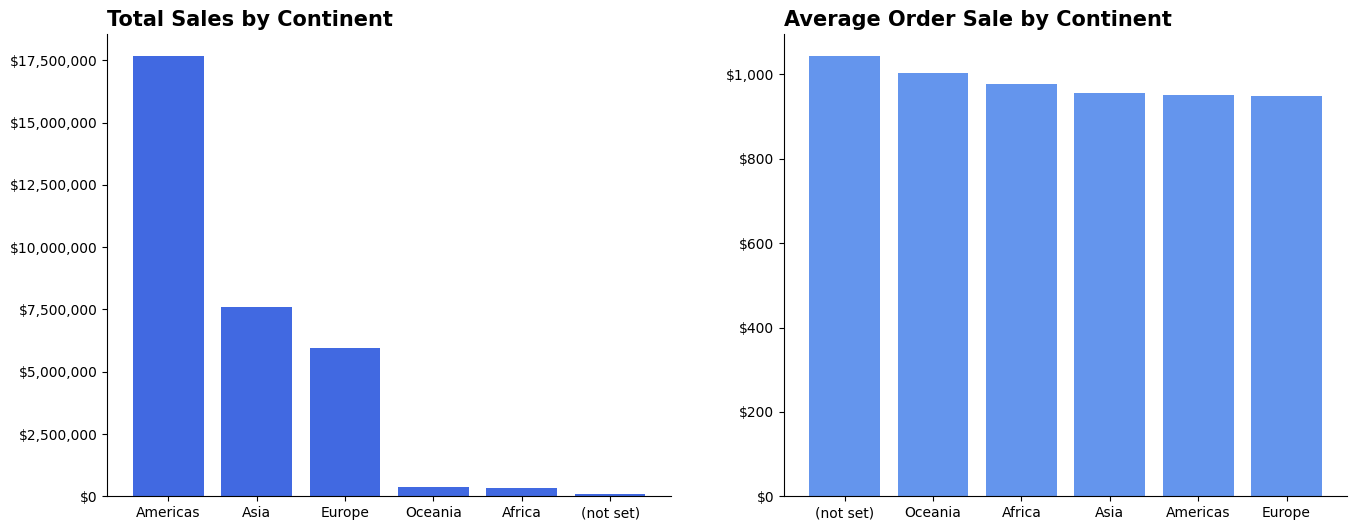

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16,6))

# Total sales by continent
sales_by_continent = df.groupby('continent')['product_price'].sum().sort_values(ascending=False)


axs[0].bar(sales_by_continent.index,
           sales_by_continent.values,
           color='royalblue')
axs[0].set_title('Total Sales by Continent',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')

axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Median sale by continent

avgsales_by_continent = df.groupby('continent')['product_price'].mean().sort_values(ascending=False)

axs[1].bar(avgsales_by_continent.index,
           avgsales_by_continent.values,
           color='cornflowerblue')
axs[1].set_title('Average Order Sale by Continent',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')

axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

In [ ]:
# Median order sale by continent

df.groupby('continent')['product_price'].median().sort_values(ascending=False)

,product_price
continent,
Africa,495.0
Europe,450.0
Asia,445.0
Americas,445.0
Oceania,414.5
(not set),315.0


In [ ]:
# Sales share by continent

round(sales_by_continent * 100 /df['product_price'].sum(), 2)

,product_price
continent,
Americas,55.25
Asia,23.78
Europe,18.56
Oceania,1.14
Africa,1.04
(not set),0.23


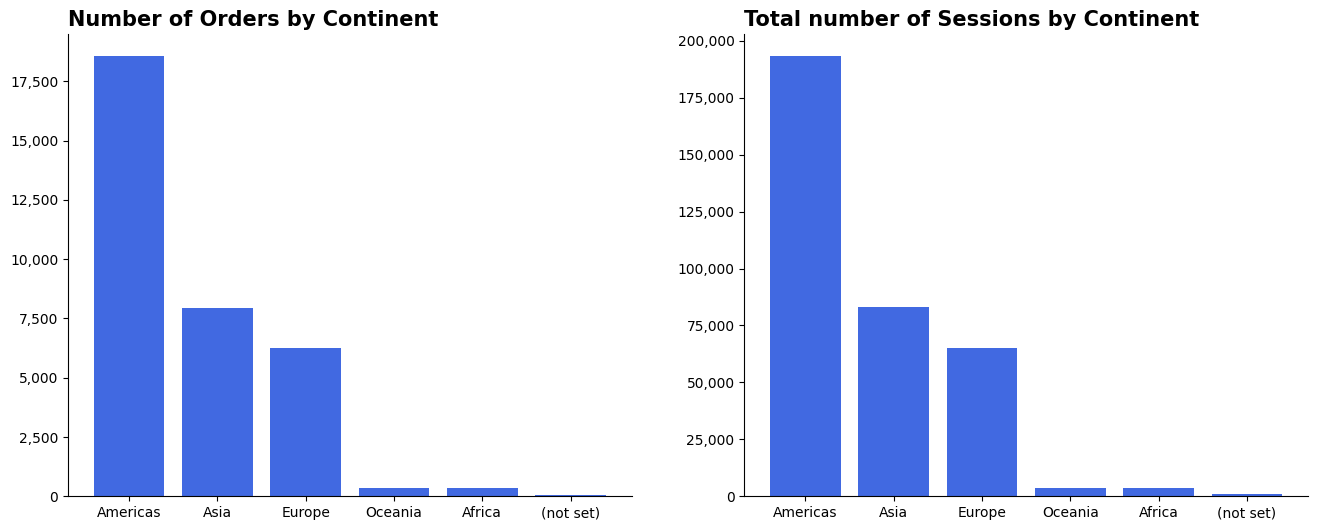

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16,6))

sessions_with_orders = df[df['product_price'].notna()]

# Sessions with orders by continent

sessions_with_orders_by_continent = sessions_with_orders.groupby('continent')['ga_session_id'].count().sort_values(ascending=False)

axs[0].bar(sessions_with_orders_by_continent.index,
           sessions_with_orders_by_continent.values,
           color='royalblue')
axs[0].set_title('Number of Orders by Continent',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


# Total sessions by continent

sessions_by_continent = df.groupby('continent')['ga_session_id'].count().sort_values(ascending=False)

axs[1].bar(sessions_by_continent.index,
           sessions_by_continent.values,
           color='royalblue')
axs[1].set_title('Total number of Sessions by Continent',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


In [ ]:
# Conversion rate (sessions with orders / total sessions)

conversion_rate_by_continent = sessions_with_orders.groupby('continent')['ga_session_id'].count() * 100/ sessions_by_continent

print(f'Conversion Rate:\n {round(conversion_rate_by_continent.sort_values(ascending=False),2)}')

Conversion Rate:
 continent
Oceania      9.83
Europe       9.61
Americas      9.6
Asia         9.57
Africa       9.36
(not set)    8.93
Name: ga_session_id, dtype: Float64


###Conclusions:
According to the charts, it is clear that the United States is by far the leading continent in terms of both sales and the total number of sessions. Its sales account for 55% of total revenue (approximately 17,500,000 USD). However, its average order value ranks only fifth among the regions.

Asia and Europe demonstrate relatively moderate performance, generating revenue in the range from 6,000,000 to 7,500,000 USD, accounting for 23.8% and 18.6%, respectively.

Oceania and Africa contribute only a modest share, each representing around 1% of total.

The Conversion Rate is relatively similar across all continents, ranging from 8.9% to 9.9%. This suggests that revenue is driven primarily by traffic volume rather than conversion efficiency.

Importantly, the average order value is approximately twice as high as the median order value, indicating that a relatively small number of high transactions increase the mean, while the majority of transactions are smaller in size.

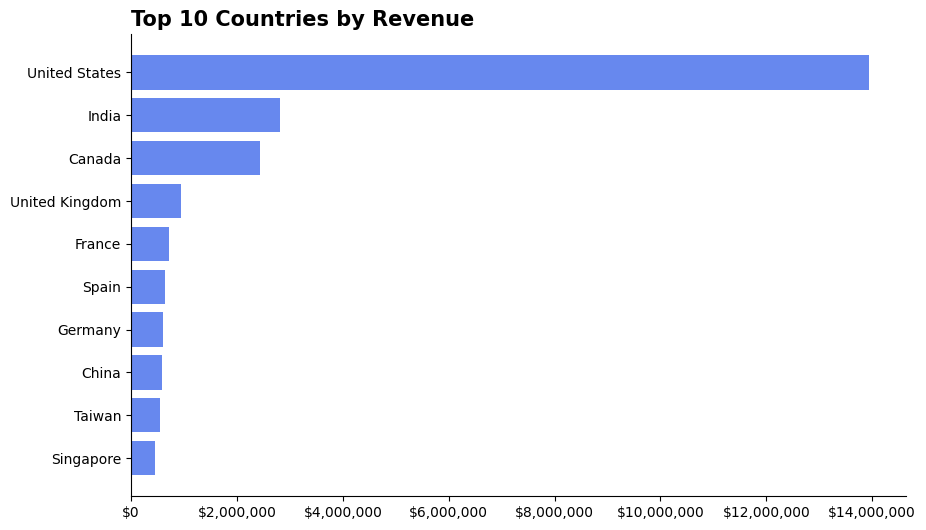

In [ ]:
# Total sales by country top 10

sales_by_country = df.groupby('country')['product_price'].sum().sort_values(ascending=False).reset_index()
sales_by_country_top = sales_by_country.head(10).sort_values(by='product_price', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(sales_by_country_top['country'],
         sales_by_country_top['product_price']
         )
plt.title('Top 10 Countries by Revenue',
          fontsize=15,
          fontweight='bold',
          loc='left')
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))



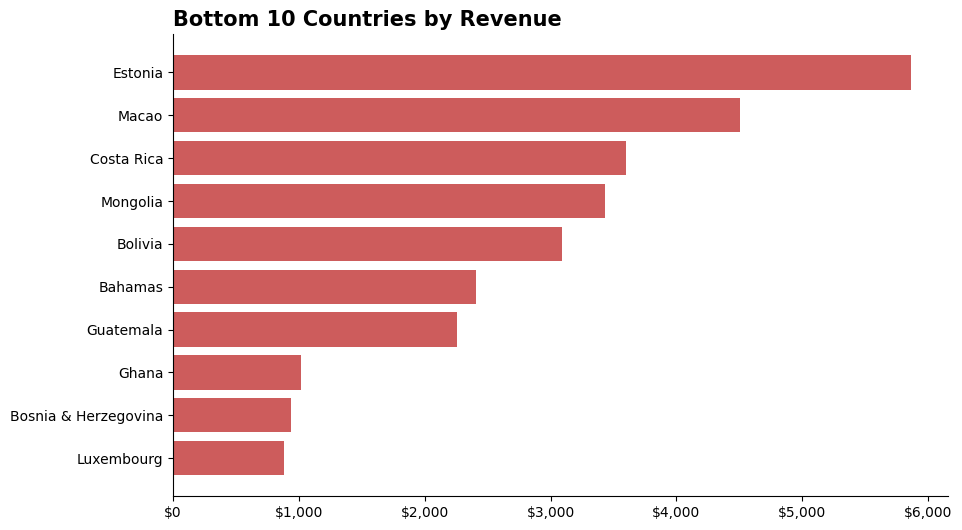

In [ ]:
# Total sales by country bottom 10

sales_by_country_bottom = sales_by_country.tail(10).sort_values(by='product_price', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(sales_by_country_bottom['country'],
         sales_by_country_bottom['product_price'],
         color ='indianred'
         )
plt.title('Bottom 10 Countries by Revenue',
          fontsize=15,
          fontweight='bold',
          loc='left')
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

In [ ]:
# Sales share out of Total of all countries

df.groupby('country')['product_price'].sum().sort_values(ascending=False) * 100 / df['product_price'].sum()

,product_price
country,
United States,43.612133
India,8.788270
Canada,7.625239
United Kingdom,2.934836
France,2.222879
...,...
Bahamas,0.007541
Guatemala,0.007066
Ghana,0.003184


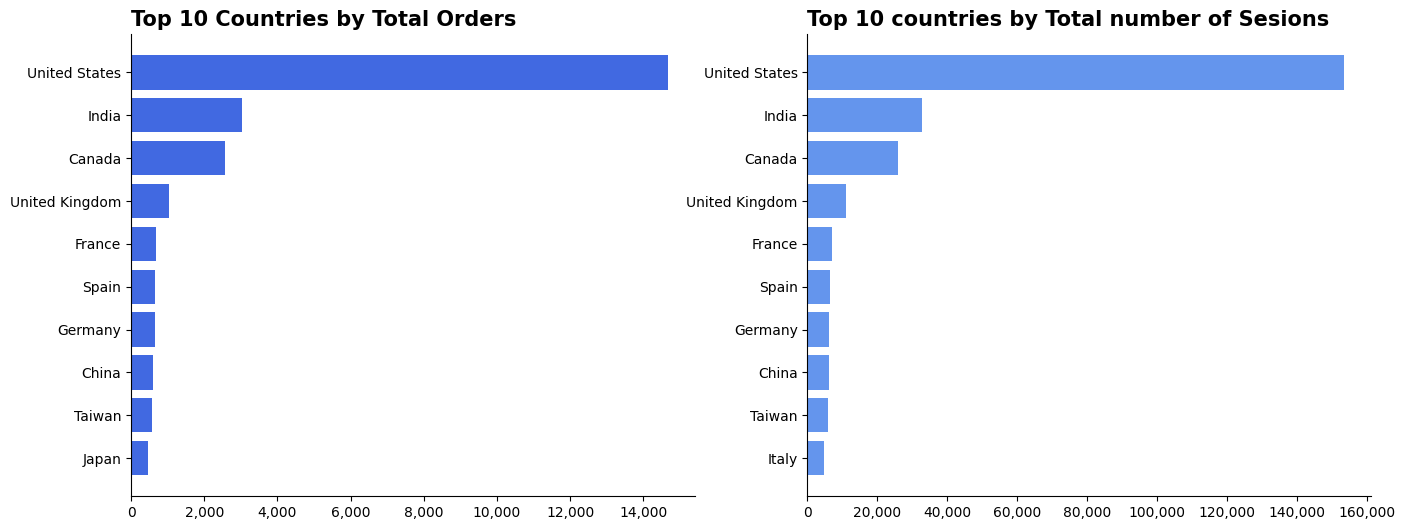

In [ ]:

fig, axs = plt.subplots(1, 2, figsize=(16,6))

# Sessions with orders by country top 10
sessions_with_orders_by_country = sessions_with_orders.groupby('country')['ga_session_id'].count().sort_values(ascending=False).head(10)
sessions_with_orders_by_country = sessions_with_orders_by_country.sort_values(ascending=True)

axs[0].barh(sessions_with_orders_by_country.index,
           sessions_with_orders_by_country.values,
           color='royalblue')
axs[0].set_title('Top 10 Countries by Total Orders',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


# Sessions by continent top 10
sessions_by_country = df.groupby('country')['ga_session_id'].count().sort_values(ascending=False).head(10)
sessions_by_country = sessions_by_country.sort_values(ascending=True)

axs[1].barh(sessions_by_country.index,
           sessions_by_country.values,
           color='cornflowerblue')
axs[1].set_title('Top 10 countries by Total number of Sesions',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


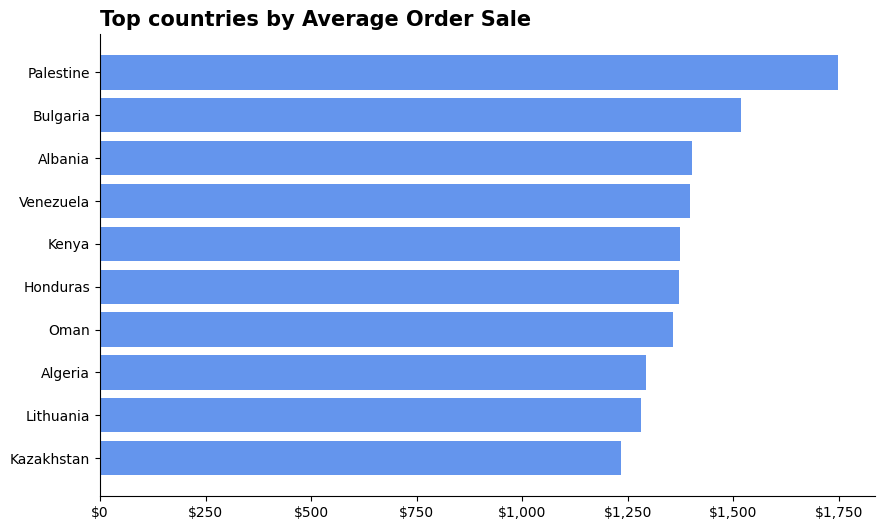

In [ ]:
# Top countries by average order sale

avgsales_by_country = df.groupby('country')['product_price'].mean().sort_values(ascending=False).head(10)
avgsales_by_country = avgsales_by_country.sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(avgsales_by_country.index,
           avgsales_by_country.values,
           color='cornflowerblue')
plt.title('Top countries by Average Order Sale',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

In [ ]:
# Median order sale by country

df.groupby('country')['product_price'].median().sort_values(ascending=False)

,product_price
country,
Palestine,1120.0
Iceland,795.0
Jamaica,760.0
Cambodia,695.0
Paraguay,695.0
...,...
Lebanon,145.0
Bahrain,115.0
Ghana,102.0


In [ ]:
# United States, average order sale

us = df[df['country'] == 'United States']
print(f'Average order sale, United States: {us['product_price'].mean()}')
print(f'Median order sale, United States: {us['product_price'].median()}')

Average order sale, United States: 950.2865058270293
Median order sale, United States: 440.0


###Conclusions:
Revenue distribution accross countries is highly uneven, with the United States dominating total sales and sessions, accounting for 43.6% share of total revenue, while the bottom countries contribute insignificantly. The average order sale of US is 950 USD, the median - 440 USD. India and UK rank second and third by total revenue and account for 8.7% and 7.6%, which are considerably less shares.

We can see that revenue is driven primarily by traffic volume rather than  high average order sale. Palestine has the highest average order value of around 1,750 USD. Nevertheless, other countries in top 10 do not fall drastically behind and demonstrate relatively high figures of 1,500 USD as well.

## Category

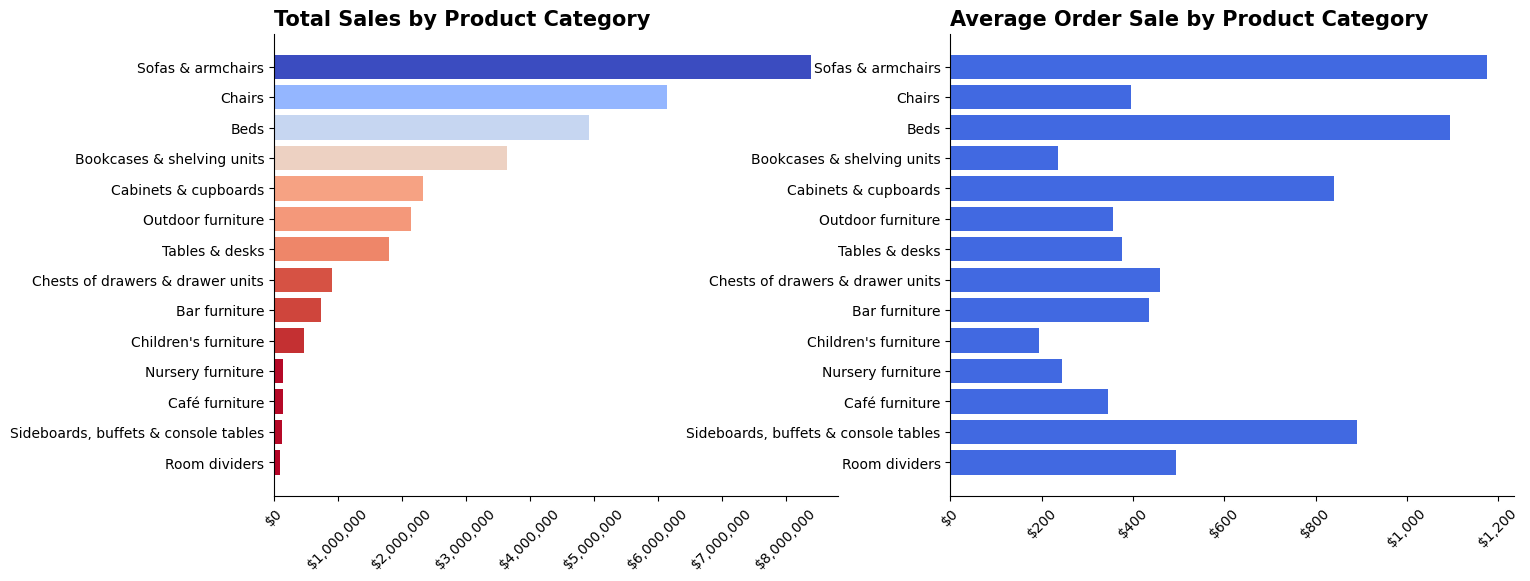

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16,6))

# Total sales by product category

sales_by_category = df.groupby('product_category')['product_price'].sum().sort_values(ascending=False)
sales_by_category = sales_by_category.sort_values(ascending=True)

values = sales_by_category.values
norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
cmap = cm.coolwarm_r
colors = cmap(norm(values))

axs[0].barh(sales_by_category.index,
            sales_by_category.values,
            color = colors)
axs[0].set_title('Total Sales by Product Category',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axs[0].tick_params(axis='x', rotation=45)

# Average sales by product category

order = sales_by_category.sort_values().index

avgsales_by_category = df.groupby('product_category')['product_price'].median().sort_values(ascending=False)
avgsales_by_category = avgsales_by_category.reindex(order)

axs[1].barh(avgsales_by_category.index,
            avgsales_by_category.values,
            color ='royalblue')
axs[1].set_title('Average Order Sale by Product Category',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axs[1].tick_params(axis='x', rotation=45)




In [ ]:
round(sales_by_category *100 /df['product_price'].sum(),2)

,product_price
product_category,
Room dividers,0.28
"Sideboards, buffets & console tables",0.40
Café furniture,0.43
Nursery furniture,0.44
Children's furniture,1.46
Bar furniture,2.30
Chests of drawers & drawer units,2.84
Tables & desks,5.60
Outdoor furniture,6.70


In [ ]:

# Function to see categories by different countries

def bar_category_sales_by_category(df, country):

    country_df = df[df['country'] == country]

    sales_by_category = (
        country_df
        .groupby('product_category')['product_price']
        .sum()
        .sort_values(ascending=True)
    )

    plt.figure(figsize=(10,6))

    plt.barh(
        sales_by_category.index,
        sales_by_category.values,
        color='royalblue'
    )

    plt.title(
        f'Total Sales by Product Category, {country}',
        fontsize=14,
        fontweight='bold',
        loc='left'
    )
    ax = plt.gca()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.xaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )

    ax.tick_params(axis='x', rotation=45)


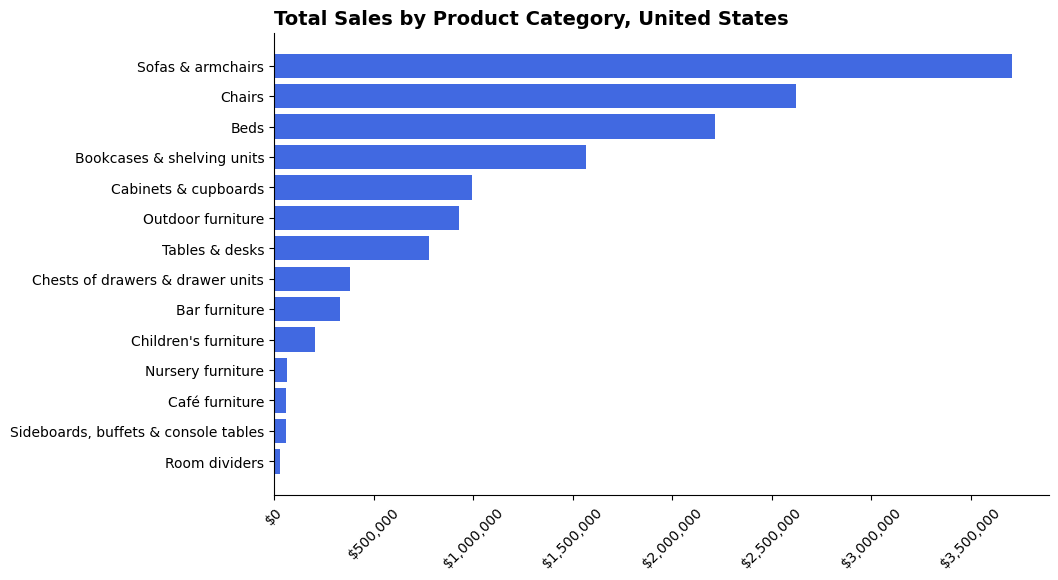

In [ ]:
bar_category_sales_by_category(df, 'United States')
plt.show()


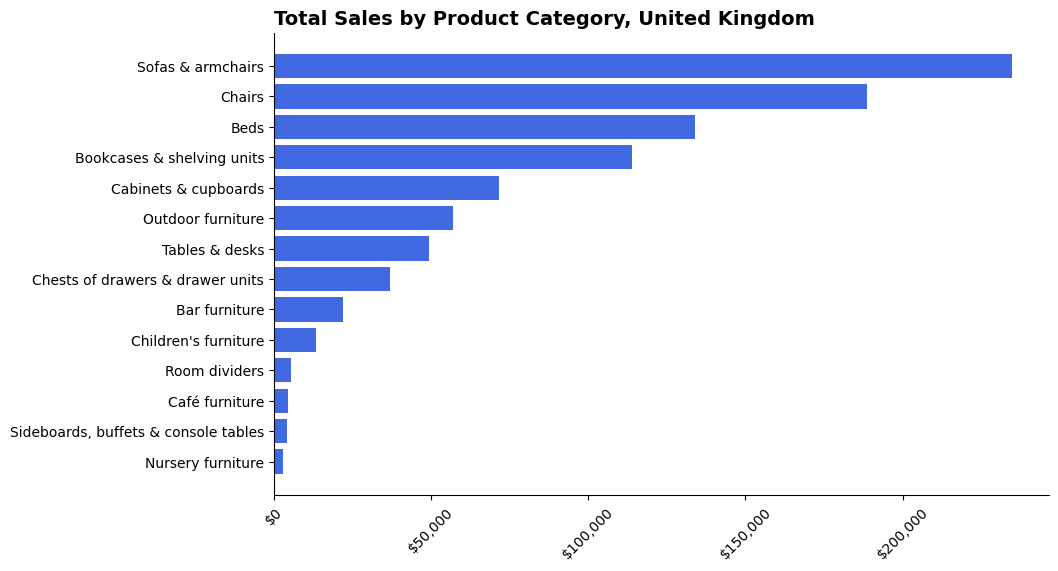

In [ ]:
bar_category_sales_by_category(df, 'United Kingdom')

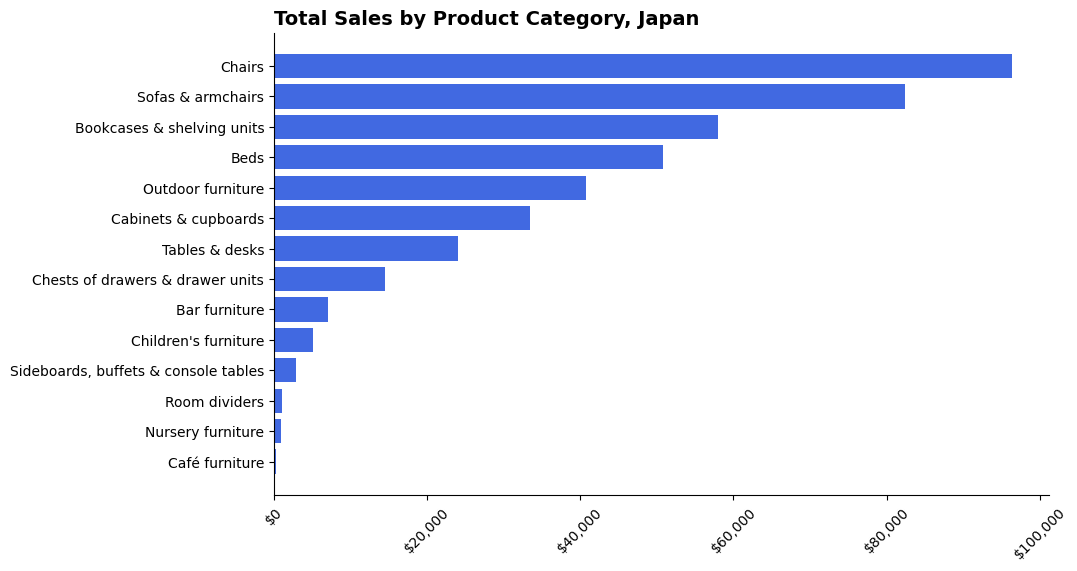

In [ ]:
bar_category_sales_by_category(df, 'Japan')

In [ ]:
country_df = df[df['country'] == 'Japan']
sales_by_category_j = (
        country_df
        .groupby('product_category')['product_price']
        .sum()
        .sort_values(ascending=True)
    )

round(sales_by_category_j *100 /country_df['product_price'].sum(),2)

,product_price
product_category,
Café furniture,0.07
Nursery furniture,0.22
Room dividers,0.25
"Sideboards, buffets & console tables",0.70
Children's furniture,1.22
Bar furniture,1.69
Chests of drawers & drawer units,3.47
Tables & desks,5.74
Cabinets & cupboards,8.00


###Conclusions:
According to the bar charts, there are five categories which make almost 80% of company's total revenue:
```
Sofas & armchairs	          26.24%
Chairs          	          19.23%
Beds	                      15.39%
Bookcases & shelving units    11.39%
Cabinets & cupboards.         7.31%
```
The pattern is largely consistent across the leading countries, particularly in the United States, which influences significantly the overall revenue distribution.

In other markets, such as Japan, sales by category differ slightly, but the top five categories remain the primary revenue drivers.

The revenue is highly concentrated in a few categories, which highlights strong dependence on core products. While this indicates clear strengths, it also suggests potential risk if demand shifts. Expanding focus on mid- and low-performing categories could help diversify revenue and capture additional growth opportunities.

Text(0.5, 1.0, 'Device Revenue Share, %')

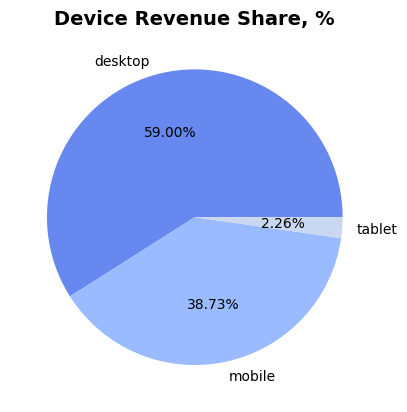

In [ ]:
# Sales share by device type

sales_by_device = df.groupby('device')['product_price'].sum().reset_index()
sns.set_palette('coolwarm')

plt.pie(sales_by_device['product_price'],
        labels = sales_by_device['device'],
        autopct='%.2f%%')

plt.title('Device Revenue Share, %',
          fontsize=14,
          fontweight='bold')

In [ ]:
df.groupby('device')['ga_session_id'].count() * 100/ df['ga_session_id'].count()


,ga_session_id
device,
desktop,58.484315
mobile,39.270194
tablet,2.245491


###Conclusions:
The pie chart shows that a large portion of revenue, 59%, comes from desktop devices. 38.7% comes from mobile devices. Only 2.3% comes from tablet. This indicates customers shopping preferences.


[Text(0, 3, '27.8%'),
 Text(0, 3, '20.4%'),
 Text(0, 3, '20.3%'),
 Text(0, 3, '20.1%'),
 Text(0, 3, '5.7%'),
 Text(0, 3, '2.2%'),
 Text(0, 3, '1.4%'),
 Text(0, 3, '1.3%'),
 Text(0, 3, '0.4%'),
 Text(0, 3, '0.3%')]

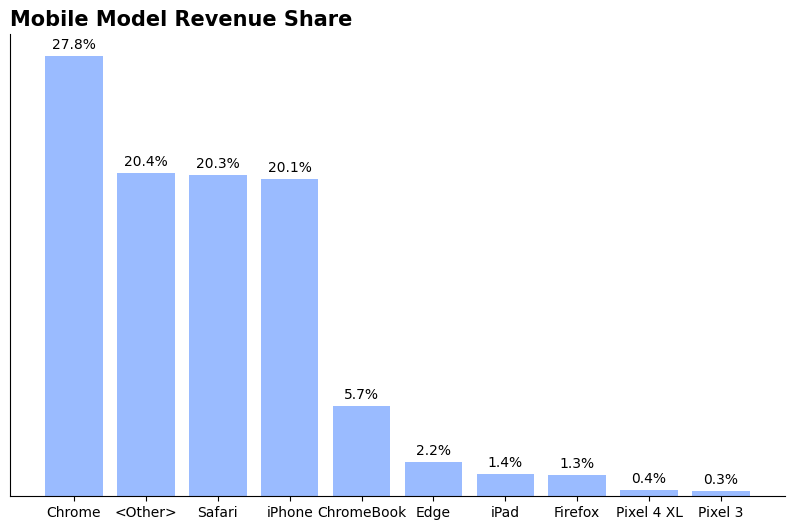

In [ ]:
# Sales share by mobile model

sales_by_mobile_model = df.groupby('mobile_model_name')['product_price'].sum().sort_values(ascending=False) * 100 / df['product_price'].sum()

plt.figure(figsize=(10,6))
plt.bar(sales_by_mobile_model.index,
        sales_by_mobile_model.values)

plt.title('Mobile Model Revenue Share',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks([])

bars = plt.bar(sales_by_mobile_model.index, sales_by_mobile_model.values)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)



In [ ]:
df.groupby('mobile_model_name')['ga_session_id'].count() * 100/ df['ga_session_id'].count()


,ga_session_id
mobile_model_name,
<Other>,20.26606
Chrome,27.823027
ChromeBook,5.459669
Edge,2.262084
Firefox,1.394384
Pixel 3,0.295813
Pixel 4 XL,0.356463
Safari,20.280937
iPad,1.456179


[Text(0, 3, '68.3%'),
 Text(0, 3, '23.5%'),
 Text(0, 3, '2.9%'),
 Text(0, 3, '2.2%'),
 Text(0, 3, '1.8%'),
 Text(0, 3, '1.3%')]

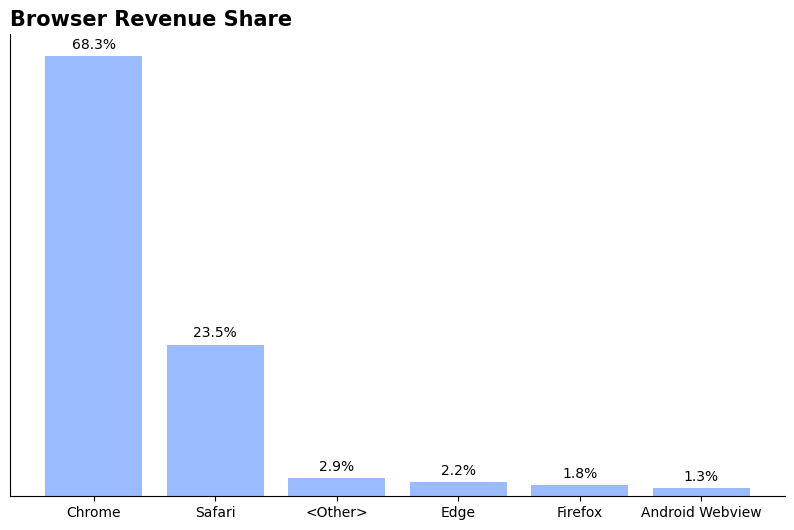

In [ ]:
# Sales share by browser

sales_by_browser = df.groupby('browser')['product_price'].sum().sort_values(ascending=False) * 100 / df['product_price'].sum()

plt.figure(figsize=(10,6))
plt.bar(sales_by_browser.index,
        sales_by_browser.values)

plt.title('Browser Revenue Share',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks([])

bars = plt.bar(sales_by_browser.index, sales_by_browser.values)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)


In [ ]:
# Comparing total session shares to revenue shares out of total

df.groupby('browser')['ga_session_id'].count() * 100/ df['ga_session_id'].count()


,ga_session_id
browser,
<Other>,2.55475
Android Webview,1.271653
Chrome,68.220115
Edge,2.29527
Firefox,1.840393
Safari,23.81782


Text(0.5, 1.0, 'Channel Revenue Share, %')

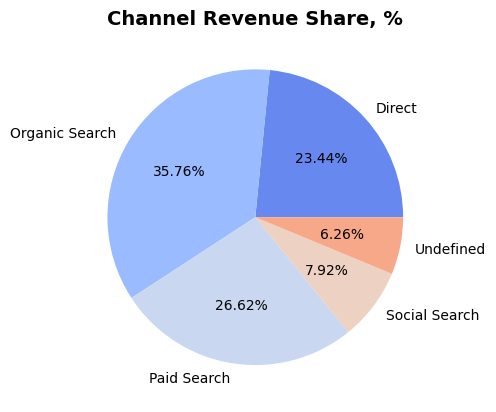

In [ ]:
# Sale share by channel

sales_by_channel = df.groupby('channel')['product_price'].sum().reset_index()
sns.set_palette('coolwarm')

plt.pie(sales_by_channel['product_price'],
        labels = sales_by_channel['channel'],
        autopct='%.2f%%')

plt.title('Channel Revenue Share, %',
          fontsize=14,
          fontweight='bold')

###Conclusions:
According to the chart, the most popular browsers among company's customers are Chrome, accounting for 68% out of total, and Safari - 23.5%.

The revenue distribution shows that Organic Search is the dominant channel, contributing 35.76% of total revenue. Paid Search follows with 26.62%, while Direct traffic accounts for 23.44%, indicating strong brand recognition and returning users.

In contrast, Social Search (7.92%) and Undefined sources (6.26%) contribute relatively small shares of revenue.

This highlights the importance of continued investment in SEO strategies, while also presenting an opportunity to optimize social and properly track undefined traffic sources to potentially increase their contribution.

## Registered customers

In [ ]:
registered_sessions = df[df['customer_id'].notna()]
registered_sessions_with_orders = df[(df['customer_id'].notna()) & (df['product_name'].notna()) ]
print(f'Percantage of registered sessions: {round(registered_sessions.shape[0] * 100 / df.shape[0],2)}%')
print(f'Percantage of sessions with orders while registered: {round(registered_sessions_with_orders.shape[0] * 100 / df.shape[0],2)}%')
print(f'Percantage of sessions with orders: {round(sessions_with_orders.shape[0] * 100 / df.shape[0],2)}%')
print(f'Percentage of verification email (where 1 = Yes, 0 = No):\n {round(registered_sessions['email_is_verified'].value_counts() * 100 / registered_sessions.shape[0], 2) }')
print(f'\nPercentage of email unsubscription (where 1 = Yes, 0 = No, did not unsubscribed:\n {round(registered_sessions['email_is_unsubscribed'].value_counts() * 100/ registered_sessions.shape[0],2)}')

Percantage of registered sessions: 7.99%
Percantage of sessions with orders while registered: 0.8%
Percantage of sessions with orders: 9.59%
Percentage of verification email (where 1 = Yes, 0 = No):
 email_is_verified
1    71.7
0    28.3
Name: count, dtype: Float64

Percentage of email unsubscription (where 1 = Yes, 0 = No, did not unsubscribed:
 email_is_unsubscribed
0    83.06
1    16.94
Name: count, dtype: Float64


###Conclusions:
The analysis reveals several important insights about user registration, purchasing behavior, and email engagement:

1. Only a small portion of total sessions belongs to registered users - 7.99%. This suggests that the majority of traffic comes from unregistered (guest) users.

2. Despite being registered, only 0.8% of sessions result in an order. This indicates either:

   * weak conversion among registered users, or
   * that registration is not strongly linked to purchase intent.

3. Overall sessions with orders (9.59%)
   The overall purchase rate (9.59%) is significantly higher than the rate among registered sessions (0.8%).
   This may suggest that many purchases are happening from **guest users**, which could mean:

   * users prefer faster checkout without registration
   * the registration flow may create friction

4. High email verification rate (71.7%), which is positive.

5. Relatively low unsubscribe rate (16.94%). Over 83% of users remain subscribed, indicating healthy email retention and potential for lifecycle marketing campaigns.


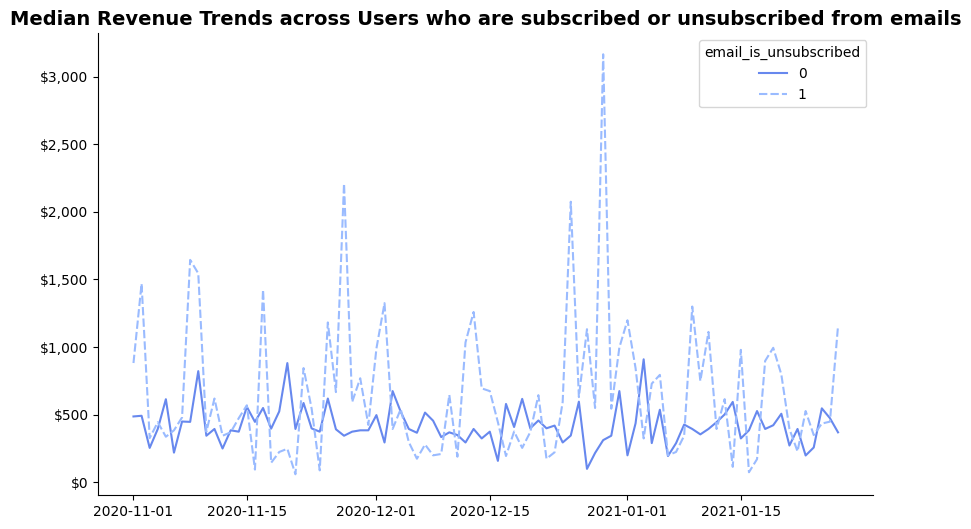

In [ ]:
# Median Revenue per day unsubscribed vs subscribed users

sales_email_subscription_median = pd.pivot_table(df, index='date', columns='email_is_unsubscribed', values='product_price', aggfunc='median')

plt.figure(figsize=(10,6))
sns.lineplot(sales_email_subscription_median)
plt.title('Median Revenue Trends across Users who are subscribed or unsubscribed from emails',
          fontsize=14,
          fontweight='bold')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

In [ ]:
# Total sales per date from subscribed vs unsubscribed users

sales_email_subscription = pd.pivot_table(df, index='date', columns='email_is_unsubscribed', values='product_price', aggfunc='sum')

In [ ]:

print(f'Number of subscribed users: {df[df['email_is_unsubscribed'] == 0].shape[0]}')
print(f'Number of unsubscribed users: {df[df['email_is_unsubscribed'] == 1].shape[0]}')

print(f'\nMedian Total Revenue from subscribed users per day: ${sales_email_subscription[0].median()} ')
print(f'Median Total Revenue from unsubscribed users per day: ${sales_email_subscription[1].median()} ')

print(f'\nTotal Revenue from subscribed users: ${round(sales_email_subscription[0].sum(),2)}')
print(f'Total Revenue from unsubscribed users: ${sales_email_subscription[1].sum()}')


Number of subscribed users: 23210
Number of unsubscribed users: 4735

Median Total Revenue from subscribed users per day: $23863.8 
Median Total Revenue from unsubscribed users per day: $3823.0 

Total Revenue from subscribed users: $2150796.9
Total Revenue from unsubscribed users: $431721.6




Subscribed users (0) show relatively stable median revenue over time.

Unsubscribed users (1) exhibit much higher volatility, with several sharp spikes in median revenue, sometimes far exceeding the subscribed group. Unsubscribed users seem to be higher-value customers.
They spend more per person (higher median).

Subscribed users represent volume, not value.
They are many, but individually spend less.


In [ ]:
df['customer_id'].nunique()

27945

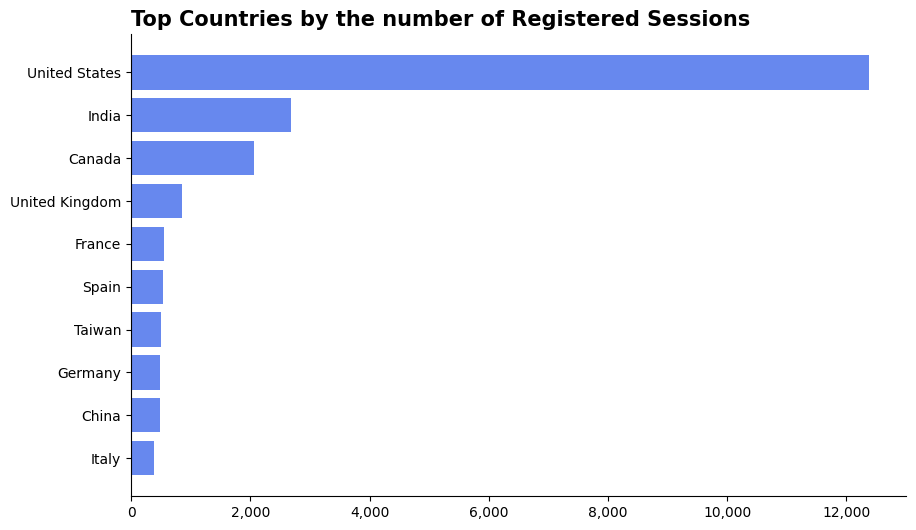

In [ ]:
registered_sessions_by_c = registered_sessions.groupby('country')['ga_session_id'].count().sort_values(ascending=False).head(10)
registered_sessions_by_country = registered_sessions_by_c.sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(registered_sessions_by_country.index,
         registered_sessions_by_country.values)

plt.title('Top Countries by the number of Registered Sessions',
                 fontsize=15,
                 fontweight='bold',
                 loc='left')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

###Connclusions:
The distribution pattern of registered sessions among countries is relatively similar to the revenue and sessions distriution.

##Sales Dynamics

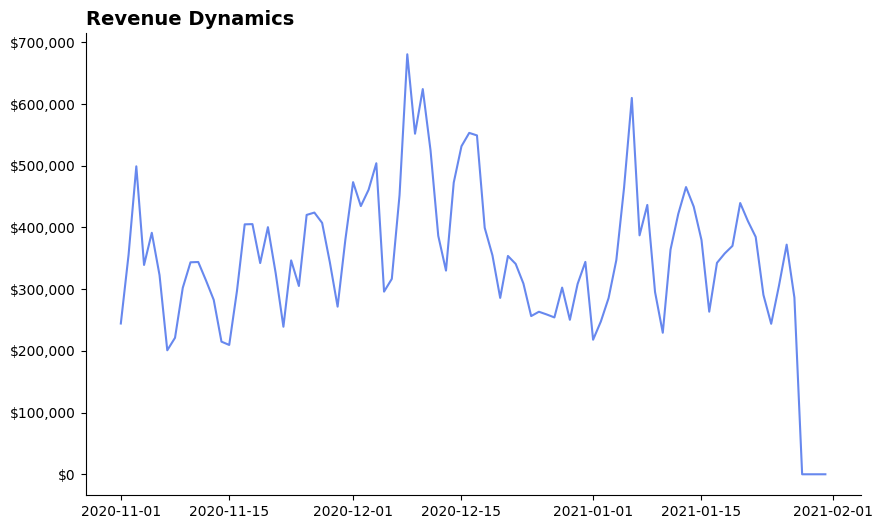

In [ ]:
sales_dynamics = df.groupby('date')['product_price'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(sales_dynamics['date'],
         sales_dynamics['product_price'])

plt.title('Revenue Dynamics',
        fontsize=14,
        fontweight='bold',
        loc='left'
    )
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )



Text(0.5, 0, '')

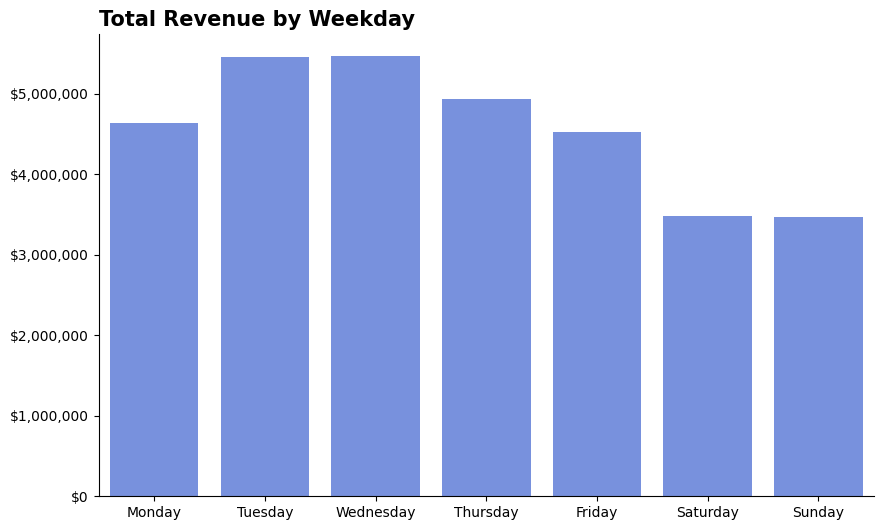

In [ ]:
# Creating a new column = day of week

df['date'] = pd.to_datetime(df['date']) # Converting to date to datetime format
df['day_of_week'] = df['date'].dt.day_name()


# Total sales by day of week

sales_by_day_of_week = df.groupby('day_of_week')['product_price'].sum()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,6))

sns.barplot(
    x=sales_by_day_of_week.index,
    y=sales_by_day_of_week.values,
    order=order
)
plt.title('Total Revenue by Weekday',
          fontsize=15,
          fontweight='bold',
          loc = 'left')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_xlabel('')


Text(0.5, 0, '')

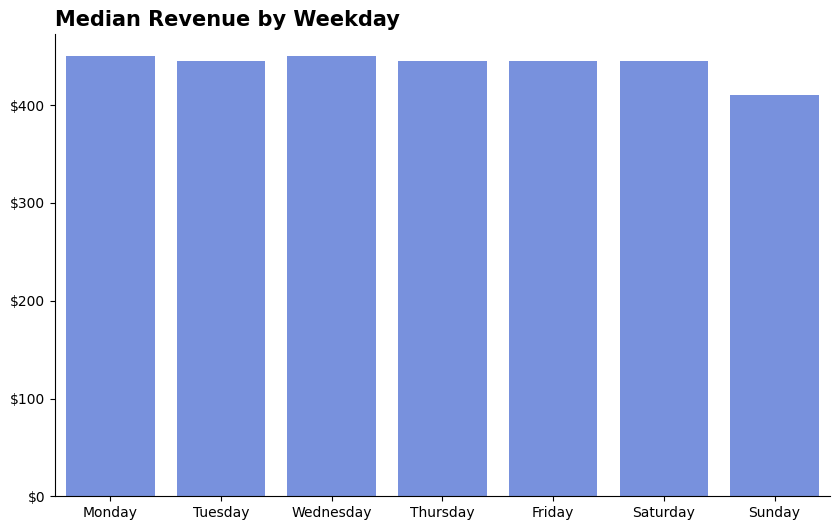

In [ ]:
# Median sales by day of week

sales_by_day_of_week = df.groupby('day_of_week')['product_price'].median()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,6))

sns.barplot(
    x=sales_by_day_of_week.index,
    y=sales_by_day_of_week.values,
    order=order
)
plt.title('Median Revenue by Weekday',
          fontsize=15,
          fontweight='bold',
          loc = 'left')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_xlabel('')

In [ ]:
df['continent'].unique()

array(['Americas', 'Europe', 'Africa', 'Asia', 'Oceania', '(not set)'],
      dtype=object)

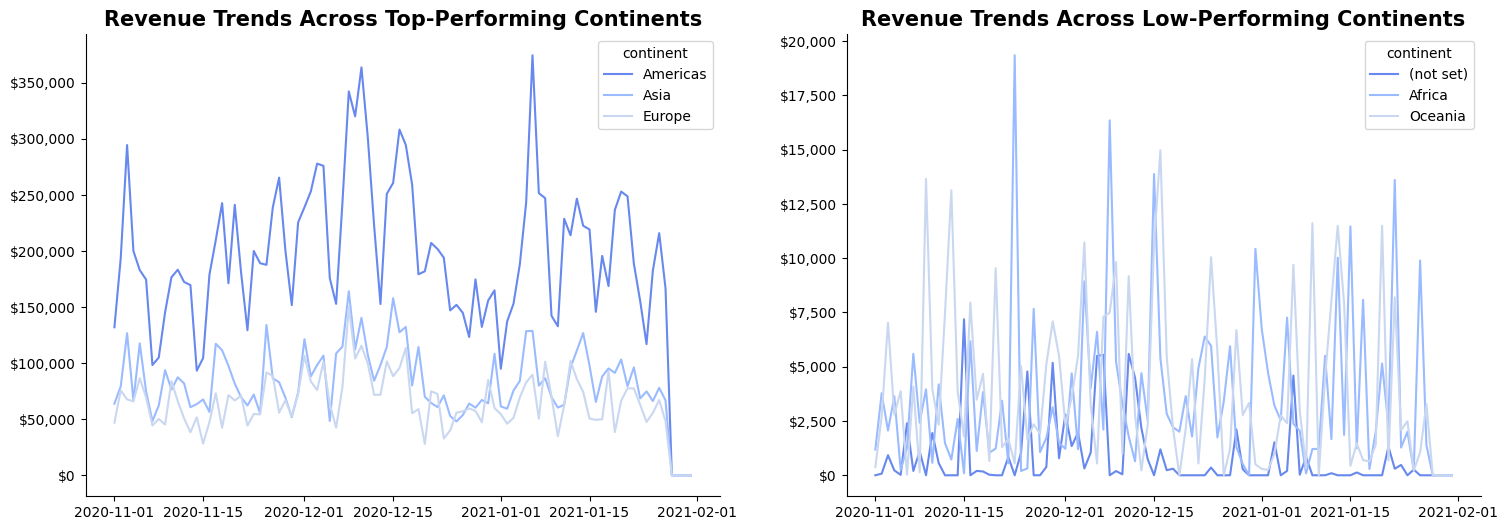

In [ ]:
# Revenue Trends by Continent

sales_dynamics_by_continents = df.groupby(['date', 'continent'])['product_price'].sum().reset_index()
sales_dynamics_by_continents_1 = sales_dynamics_by_continents[(sales_dynamics_by_continents['continent'] == 'Americas') | (sales_dynamics_by_continents['continent'] == 'Europe') | (sales_dynamics_by_continents['continent'] == 'Asia')]
sales_dynamics_by_continents_2 = sales_dynamics_by_continents[(sales_dynamics_by_continents['continent'] == 'Oceania') | (sales_dynamics_by_continents['continent'] == '(not set)') | (sales_dynamics_by_continents['continent'] == 'Africa')]

fig, axs = plt.subplots(1, 2, figsize=(18,6))

sns.lineplot(data = sales_dynamics_by_continents_1,
            x = 'date',
            y = 'product_price',
            hue = 'continent' ,
             ax = axs[0])

axs[0].set_title('Revenue Trends Across Top-Performing Continents',
          fontsize = 15,
          fontweight = 'bold')

axs[0].set_ylabel('')
axs[0].set_xlabel('')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[0].yaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )


sns.lineplot(data = sales_dynamics_by_continents_2,
            x = 'date',
            y = 'product_price',
            hue = 'continent' ,
             ax = axs[1])

axs[1].set_title('Revenue Trends Across Low-Performing Continents',
          fontsize = 15,
          fontweight = 'bold')

axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[1].yaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )



<Figure size 1000x600 with 0 Axes>

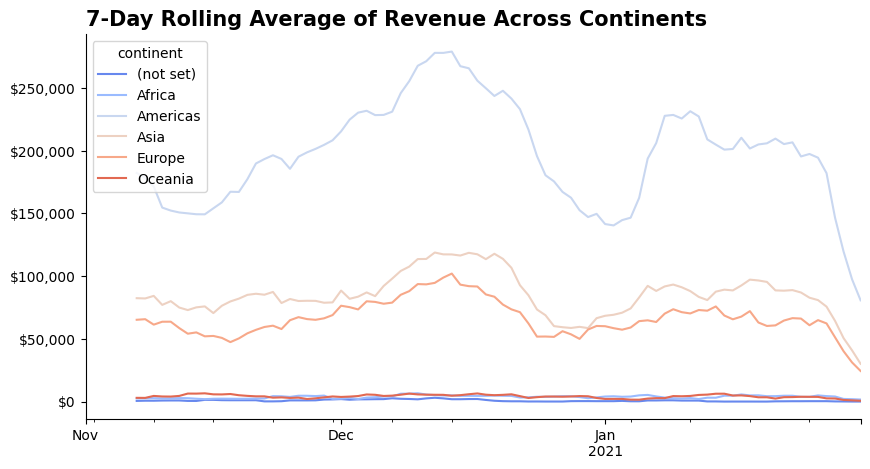

In [ ]:
# Creating a pivot table for further revenue trends analysis

pivot_revenue_by_continent = pd.pivot_table(df, values='product_price', index='date', columns='continent', aggfunc='sum')

# Rolling Average 7 days

pivot_revenue_by_continent_rolling = pivot_revenue_by_continent.rolling(7).mean()

plt.figure(figsize=(10,6))

pivot_revenue_by_continent_rolling.plot(figsize=(10,5))
plt.title('7-Day Rolling Average of Revenue Across Continents',
          fontsize = 15,
          fontweight = 'bold',
          loc='left')
ax = plt.gca()
ax.set_ylabel('')
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )

###Conclusions:
The Revenue Dynamics plot shows significant fluctuations in revenue over the observed period.

Revenue peaks multiple times, reaching highs around 600,000–700,000 USD, particularly in mid-December and early January.
Between these peaks, revenue experiences notable drops, indicating volatility in performance. Toward the end of January, there is a sharp decline to near-zero revenue, which may point to data cutoff.

According to the rolling Average, there is a clear seasonal trend: sales rise in late November–December, then drop sharply towards the end of December. In January sales start recovering.

On average, there is almost no difference in revenue across weekdays. However,in total, Tuesday and Wednesday are High-Performing days. Performance  moderately decreases on Thursday until it declines almost by 25% on weekends.

Overall, while the business experienced strong revenue spikes, the high variability highlights the need for strategies to stabilize income across periods.

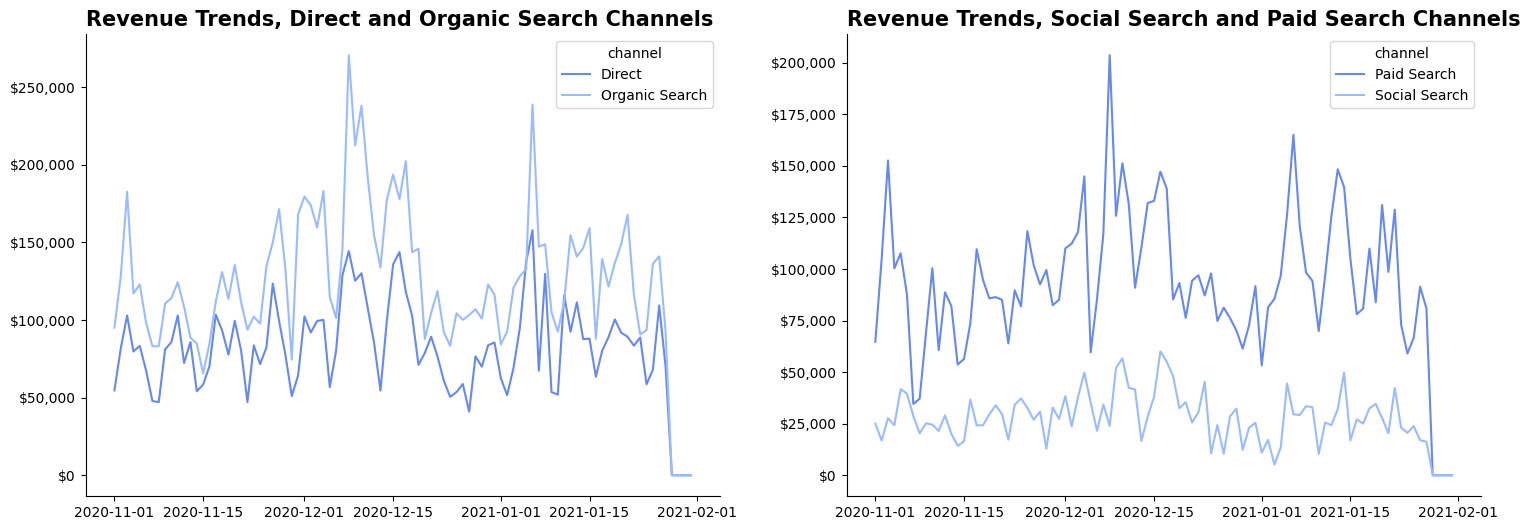

In [ ]:
# Revenue Trends Across Channels

sales_dynamics_by_channel = df.groupby(['date', 'channel'])['product_price'].sum().reset_index()
sales_dynamics_by_channel_1 = sales_dynamics_by_channel[(sales_dynamics_by_channel['channel'] == 'Direct') | (sales_dynamics_by_channel['channel'] == 'Organic Search')]
sales_dynamics_by_channel_2 = sales_dynamics_by_channel[(sales_dynamics_by_channel['channel'] == 'Social Search') | (sales_dynamics_by_channel['channel'] == 'Paid Search')]


fig, axs = plt.subplots(1, 2, figsize=(18,6))

sns.lineplot(data = sales_dynamics_by_channel_1,
            x = 'date',
            y = 'product_price',
            hue = 'channel',
             ax = axs[0])

axs[0].set_title('Revenue Trends, Direct and Organic Search Channels',
          fontsize = 15,
          fontweight = 'bold',
                 loc='left')


axs[0].set_ylabel('')
axs[0].set_xlabel('')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[0].yaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )


sns.lineplot(data = sales_dynamics_by_channel_2,
            x = 'date',
            y = 'product_price',
            hue = 'channel' ,
             ax = axs[1])

axs[1].set_title('Revenue Trends, Social Search and Paid Search Channels',
          fontsize = 15,
          fontweight = 'bold',
                 loc='left')

axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[1].yaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )


<Figure size 1000x600 with 0 Axes>

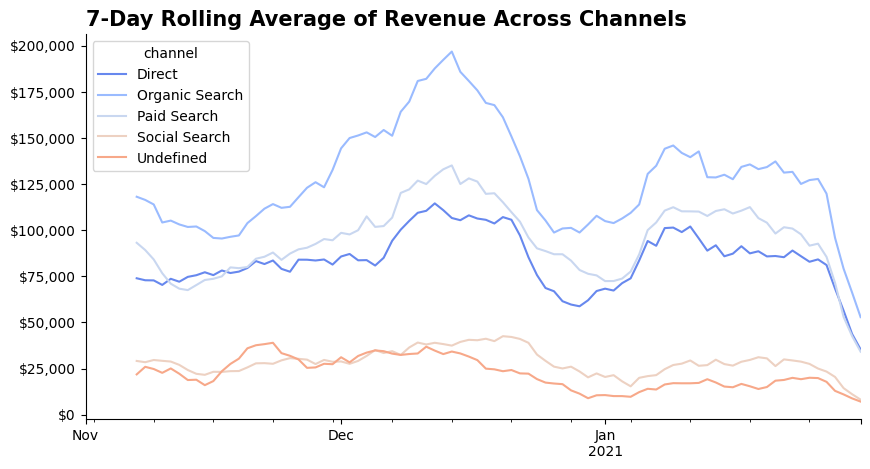

In [ ]:
pivot_revenue_by_channel = pd.pivot_table(df, values='product_price', index='date', columns='channel', aggfunc='sum')

# Rolling Average 7 days

pivot_revenue_by_channel_rolling = pivot_revenue_by_channel.rolling(7).mean()

plt.figure(figsize=(10,6))

pivot_revenue_by_channel_rolling.plot(figsize=(10,5))
plt.title('7-Day Rolling Average of Revenue Across Channels',
          fontsize = 15,
          fontweight = 'bold',
          loc='left')
ax = plt.gca()
ax.set_ylabel('')
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )

Text(0, 0.5, '')

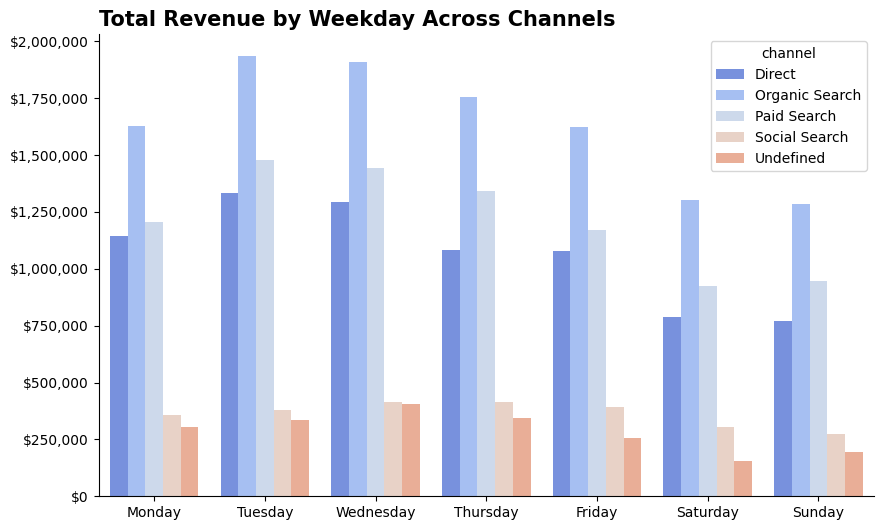

In [ ]:

# Total sales by day of week

sales_by_day_of_week_channels = df.groupby(['channel','day_of_week'])['product_price'].sum().reset_index()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,6))

sns.barplot(data = sales_by_day_of_week_channels,
     x = 'day_of_week',
     y = 'product_price',
    hue='channel',
    order=order
)
plt.title('Total Revenue by Weekday Across Channels',
          fontsize=15,
          fontweight='bold',
          loc='left')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_xlabel('')
ax.set_ylabel('')


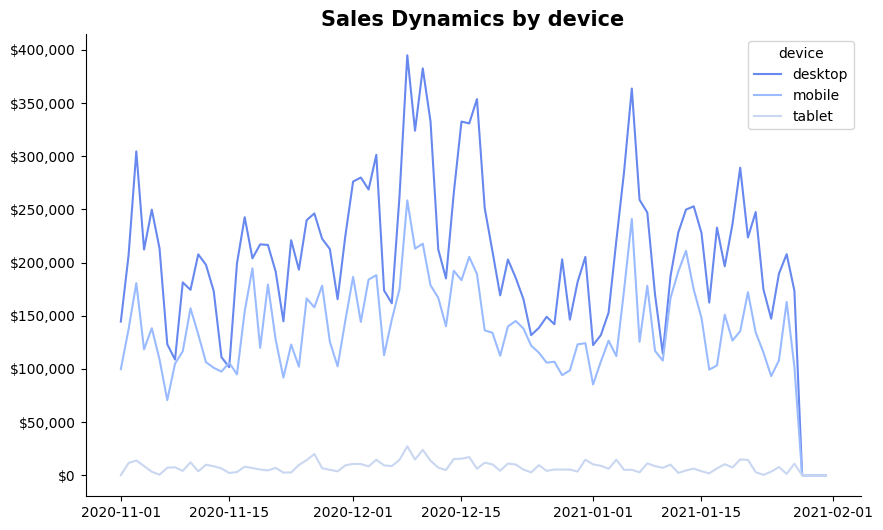

In [ ]:
sales_dynamics_by_device = df.groupby(['date', 'device'])['product_price'].sum().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(data = sales_dynamics_by_device,
            x = 'date',
            y = 'product_price',
            hue = 'device' )

plt.title('Sales Dynamics by device',
          fontsize = 15,
          fontweight = 'bold')

ax = plt.gca()
ax.set_ylabel('')
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )

## Pivot Tables

In [ ]:
# Number of sessions across different devices and channels

pd.pivot_table(df, index='channel', values='ga_session_id', columns='device', aggfunc='count')

device,desktop,mobile,tablet
channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [ ]:
# Total Revenue across different categories and continents


pd.pivot_table(df, index='product_category', values='product_price', columns='continent', aggfunc='sum').sort_values(by='Americas', ascending=False)

continent,(not set),Africa,Americas,Asia,Europe,Oceania
product_category,,,,,,
Sofas & armchairs,23345.0,108120.0,4737307.0,1950022.0,1491224.5,78236.0
Chairs,17131.0,44877.0,3309203.0,1524600.8,1178581.0,73356.0
Beds,9565.0,57567.5,2773094.0,1077325.5,925047.5,77125.5
Bookcases & shelving units,2597.0,32996.7,1968919.3,945368.9,650889.5,40046.7
Cabinets & cupboards,5127.0,21106.0,1275562.5,545369.5,468652.5,20682.0
Outdoor furniture,3131.4,16343.8,1213115.2,488607.6,399553.2,21471.0
Tables & desks,7996.0,21658.0,968129.0,464192.5,307045.0,21287.0
Chests of drawers & drawer units,2010.0,10941.0,484290.0,210383.5,186793.0,12145.0
Bar furniture,NaN,10724.0,406198.0,176684.0,131110.0,10787.0


#Statistical relationship analysis

###Correlation between Revenue and the Number of Sessions

Text(-21.18055555555555, 0.5, 'Revenue')

<Figure size 1000x600 with 0 Axes>

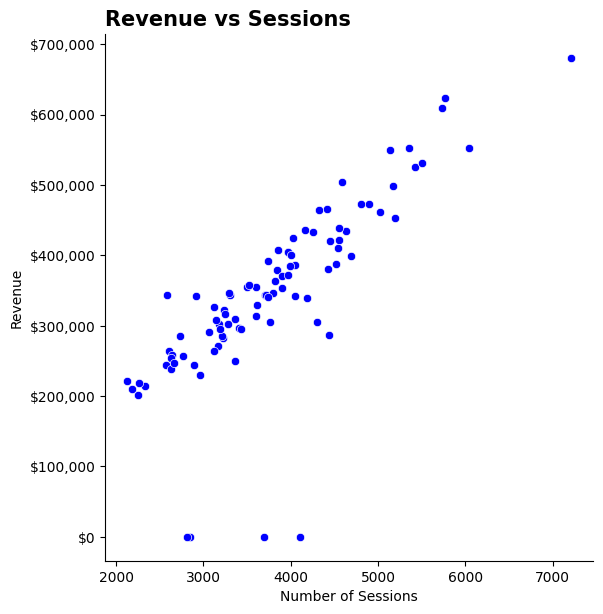

In [ ]:
df2 = df.groupby('date').agg(sessions=('ga_session_id', 'count'), revenue=('product_price', 'sum')).reset_index()

plt.figure(figsize=(10,6))
sns.relplot(data=df2,
            x='sessions',
            y='revenue',
            color='blue',
            height=6)

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

ax.set_title('Revenue vs Sessions',
             fontsize=15,
             fontweight='bold',
             loc='left')
ax.set_xlabel('Number of Sessions')
ax.set_ylabel('Revenue')

In [ ]:
# Normal Test
_, p_value_normaltest_s = normaltest(df2['sessions'])
_, p_value_normaltest_r = normaltest(df2['revenue'])

print(f'Normal test for sessions, p_value: {p_value_normaltest_s}')
print(f'Normal test for revenue, p_value: {p_value_normaltest_r}')

# p_value < 0.05, indicating that the distribution of both values is not normal

Normal test for sessions, p_value: 0.008655428822366544
Normal test for revenue, p_value: 0.021085752302202193


In [ ]:
# Statistical significance and Correlation

print(f"Test statistic and p-value: {spearmanr(df2['sessions'], df2['revenue'])}")


# Calculate Spearman correlation
spearman_corr = df2["sessions"].corr(df2["revenue"], method="spearman")
print(f"Spearman Correlation: {spearman_corr}")

Test statistic and p-value: SignificanceResult(statistic=np.float64(0.8653062174563682), pvalue=np.float64(9.755923586156614e-29))
Spearman Correlation: 0.8653062174563682


###Conclusions:
The Spearman correlation coefficient is 0.86, indicating a strong positive correlation between the number of sessions and revenue.

The p-value is less than 0.05, meaning the correlation is statistically significant at the 5% significance level.

### Revenue Correlation Across High-Performing Continents

In [ ]:
# Analysis of Variance across Top continents' revenue to determine statistical significance

pivot_top_continents = pd.pivot_table(sales_dynamics_by_continents_1, index='date',
               values='product_price',
               columns='continent',
               aggfunc='sum')

top_continents = [pivot_top_continents[col] for col in pivot_top_continents.columns]

# ANOVA-test
F_stat, p_value = f_oneway(*top_continents)

if p_value < 0.05:
    print("There is a statistically significant difference between the continents.")
else:
    print("No statistically significant difference found between the continents.")

There is a statistically significant difference between the continents.


Text(70.72222222222221, 0.5, '')

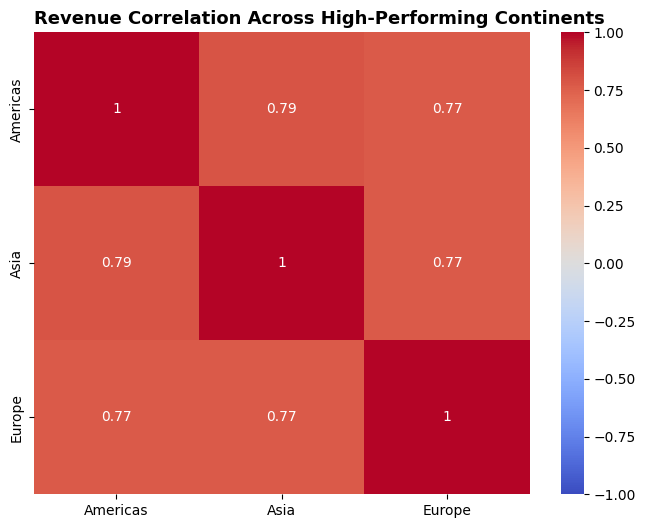

In [ ]:
# Correlation
corr_matrix_continents = pivot_top_continents.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix_continents,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)
plt.title('Revenue Correlation Across High-Performing Continents',
          fontsize=13,
          fontweight='bold',
          loc='left')
plt.xlabel('')
plt.ylabel('')

###Conclusions:
The Pearson correlation coefficients, all are higher than 0.77, indicating strong positive correlations between the revenue across High-Performing continents.
The p-value is less than 0.05, meaning the correlation is statistically significant at the 5% significance level.

### Revenue Correlation Across Channels

In [ ]:
# Analysis of Variance across channels

pivot_channels = pd.pivot_table(df, index='date',
               values='product_price',
               columns='channel',
               aggfunc='sum')

channels = [pivot_channels[col] for col in pivot_channels.columns]

# ANOVA-test
F_stat, p_value = f_oneway(*channels)

if p_value < 0.05:
    print("There is a statistically significant difference between the channels.")
else:
    print("No statistically significant difference found between the channels.")

There is a statistically significant difference between the channels.


Text(70.72222222222221, 0.5, '')

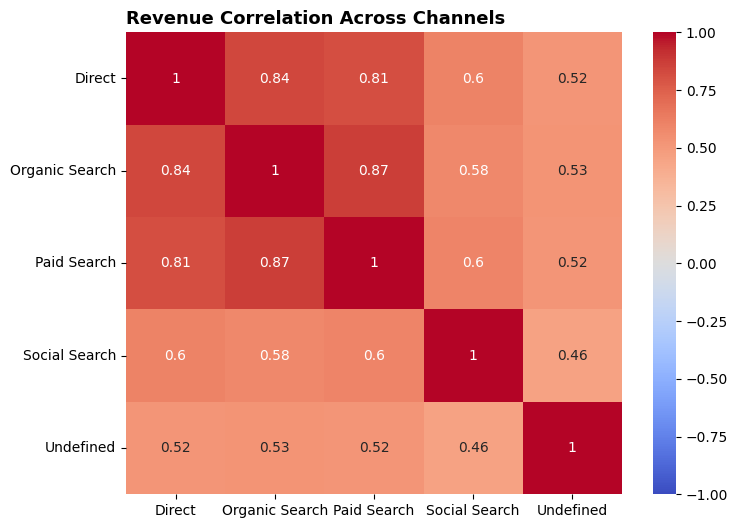

In [ ]:
# Correlation
corr_matrix_channels = pivot_channels.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix_channels,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)
plt.title('Revenue Correlation Across Channels',
          fontsize=13,
          fontweight='bold',
          loc='left')
plt.xlabel('')
plt.ylabel('')

### Conclusions:

Organic Search, Paid Search, and Direct demonstrate high correlations. This suggests that improvements in search visibility and brand presence can generate compounded effects across multiple revenue streams.

Social Search shows moderate correlations with other channels, implying it plays a supportive or assistive role rather than acting as a primary revenue driver.

The p-value is less than 0.05, meaning the correlation is statistically significant at the 5% significance level.

### Revenue Correlation Across Top Five Product Categories

In [ ]:
top_5_categories_sales = df.groupby('product_category')['product_price'].sum().sort_values(ascending=False).head(5).index
top_5_categories = df[df['product_category'].isin(top_5_categories_sales)]

In [ ]:
# Analysis of Variance across top 5 product categories

pivot_categories = pd.pivot_table(top_5_categories, index='date',
               values='product_price',
               columns='product_category',
               aggfunc='sum')

categories = [pivot_categories[col] for col in pivot_categories.columns]

# ANOVA-test
F_stat, p_value = f_oneway(*categories)

if p_value < 0.05:
    print("There is a statistically significant difference between the channels.")
else:
    print("No statistically significant difference found between the channels.")

There is a statistically significant difference between the channels.


Text(70.7222222222222, 0.5, '')

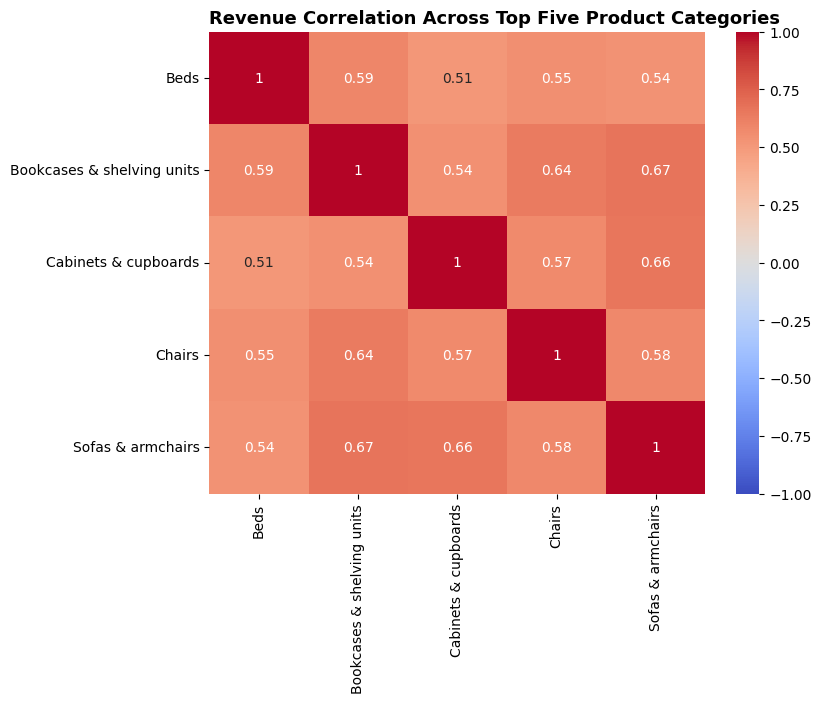

In [ ]:
# Correlation
corr_matrix_top_categories = pivot_categories.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix_top_categories,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)
plt.title('Revenue Correlation Across Top Five Product Categories',
          fontsize=13,
          fontweight='bold',
          loc='left')
plt.xlabel('')
plt.ylabel('')

###Conclusions:
All categories sales demonstrate moderate positive correlations.

#Statistical analysis of differences between groups

### Between registered and non registered users

In [ ]:
non_registered_sessions = df[df['customer_id'].isna()]

registered_sales = registered_sessions.groupby('date')['product_price'].sum()
non_registered_sales = non_registered_sessions.groupby('date')['product_price'].sum()

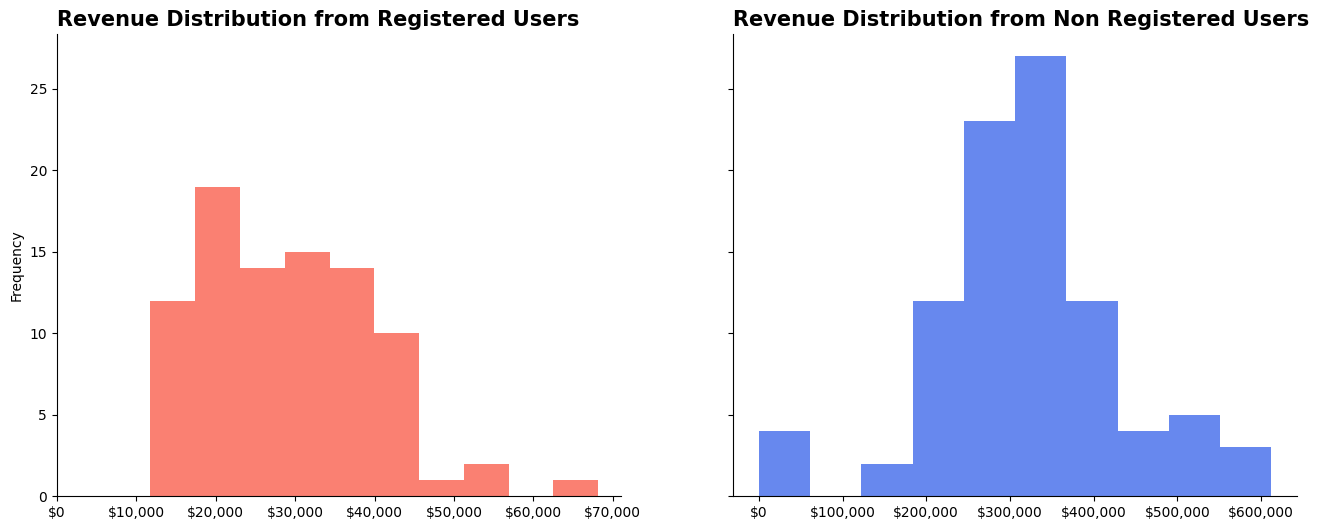

In [ ]:
fig, axs = plt.subplots( 1, 2, sharey=True, figsize=(16,6))

axs[0].hist(registered_sales, color = 'salmon')
axs[0].set_xlim(left=0)
axs[0].set_title('Revenue Distribution from Registered Users',
          fontsize = 15,
          fontweight = 'bold',
                 loc='left')


axs[0].set_ylabel('')
axs[0].set_xlabel('')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[0].xaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )
axs[0].set_ylabel('Frequency')


axs[1].hist(non_registered_sales)
axs[1].set_title('Revenue Distribution from Non Registered Users',
          fontsize = 15,
          fontweight = 'bold',
                 loc='left')



axs[1].set_xlabel('')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[1].xaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )


In [ ]:
# Non parametric statistical test to determine if there is a significant difference between two independent, non-normally distributed groups

stat, p_value_mannwhitneyu = mannwhitneyu(registered_sales, non_registered_sales)

print(f"U-statistic: {stat}")
print(f"P-value: {p_value_mannwhitneyu}")

# Interpretation
if p_value < 0.05:
    print("There is a significant difference between sales from registered and non-registered users.")
else:
    print("There is no significant difference sales from registered and non-registered users.")

U-statistic: 352.0
P-value: 3.8805185465235906e-26
There is a significant difference between sales from registered and non-registered users.


Despite the imbalance in group sizes (registered users represent only 8% of the sample), statistical testing indicates a significant difference in revenue distribution between the groups. However, due to skewness and unequal sample sizes, the effect size and median comparison should be evaluated to determine practical significance.

In [ ]:
print(f'Number of registered sessions: {registered_sessions.shape[0]}')
print(f'Number of unique cutomer_id: {df['customer_id'].nunique()}')

Number of registered sessions: 27945
Number of unique cutomer_id: 27945


In [ ]:
# There is no need to group by customer_id because there is a one-to-one relationship between sessions and customers

registered_sales_median = registered_sessions.groupby('date')['product_price'].median()
non_registered_sales_median = non_registered_sessions.groupby('date')['product_price'].median()

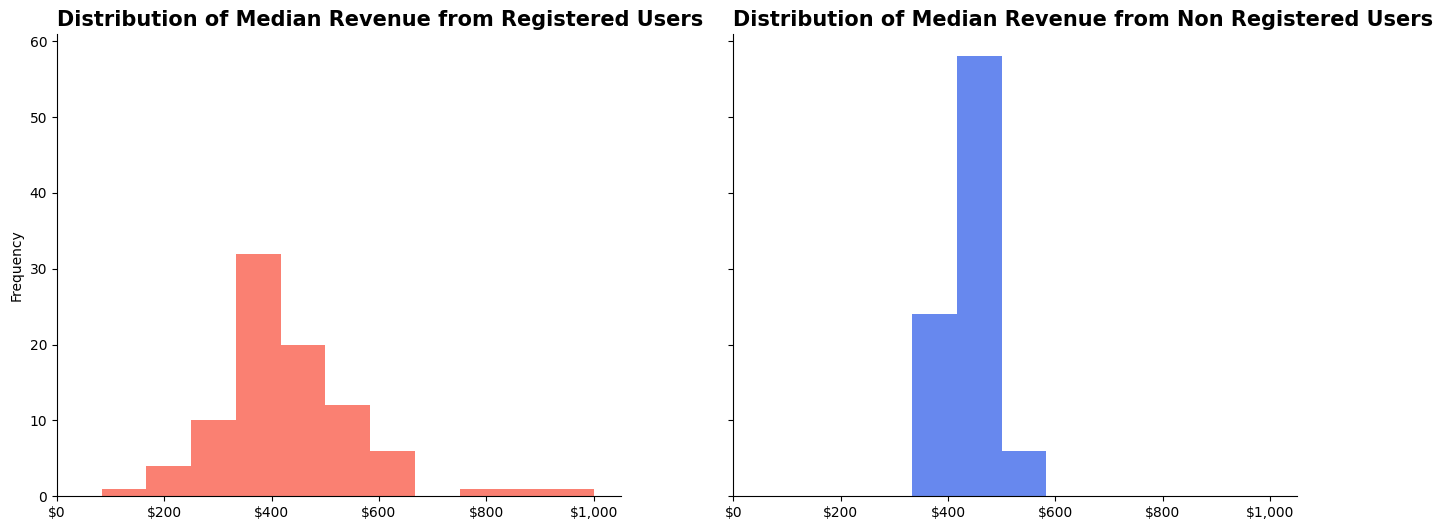

In [ ]:

fig, axs = plt.subplots( 1, 2, sharey=True, figsize=(16,6))
params = dict(bins=12, range=(0, 1000))

axs[0].hist(registered_sales_median, **params, color = 'salmon')
axs[0].set_xlim(left=0)
axs[0].set_title('Distribution of Median Revenue from Registered Users',
          fontsize = 15,
          fontweight = 'bold',
                 loc='left')


axs[0].set_ylabel('')
axs[0].set_xlabel('')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[0].xaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )
axs[0].set_ylabel('Frequency')


axs[1].hist(non_registered_sales_median, **params)
axs[1].set_title('Distribution of Median Revenue from Non Registered Users',
          fontsize = 15,
          fontweight = 'bold',
                 loc='left')



axs[1].set_xlabel('')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].set_xlim(0)


axs[1].xaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )


In [ ]:
# Normal Test

_, p_value_shapiro_registered_sales_median = shapiro(registered_sales_median)
_, p_value_shapiro_non_registered_sales_median = shapiro(non_registered_sales_median)


if p_value_shapiro_registered_sales_median > 0.05:
    print("The distribution of Revenue from Registered Users is normal.")
else:
    print("The distribution of Revenue from Registered Users is not normal.")


if p_value_shapiro_non_registered_sales_median > 0.05:
    print("The distribution of Revenue from Non-Registered Users is normal.")
else:
    print("The distribution of Revenue from Non-Registered Users is not normal.")

The distribution of Revenue from Registered Users is not normal.
The distribution of Revenue from Non-Registered Users is not normal.


In [ ]:
# Non parametric test to determine statistical significance

stat_median, p_value_mannwhitneyu_median = mannwhitneyu(registered_sales_median.dropna(), non_registered_sales_median.dropna())

print(f"U-statistic: {stat_median}")
print(f"P-value: {p_value_mannwhitneyu_median}")

# Interpretation
if p_value_mannwhitneyu_median < 0.05:
    print("There is a significant difference in sales from registered and non-registered users.")
else:
    print("There is no significant difference in sales from registered and non-registered users.")

U-statistic: 3064.0
P-value: 0.016649440608998096
There is a significant difference in sales from registered and non-registered users.


In [ ]:
print(f'Median Revenue from registered users: {registered_sales_median.median()}')
print(f'Median Revenue from non registered users: {non_registered_sales_median.median()}')

Median Revenue from registered users: 397.25
Median Revenue from non registered users: 445.0


The Mann–Whitney U test indicates a statistically significant difference in median revenue between registered and non-registered users. Although the central tendencies appear relatively close, the distribution for registered users shows greater variability and includes higher revenue values.

### Between users who are subscribed and unsubscribed from emails

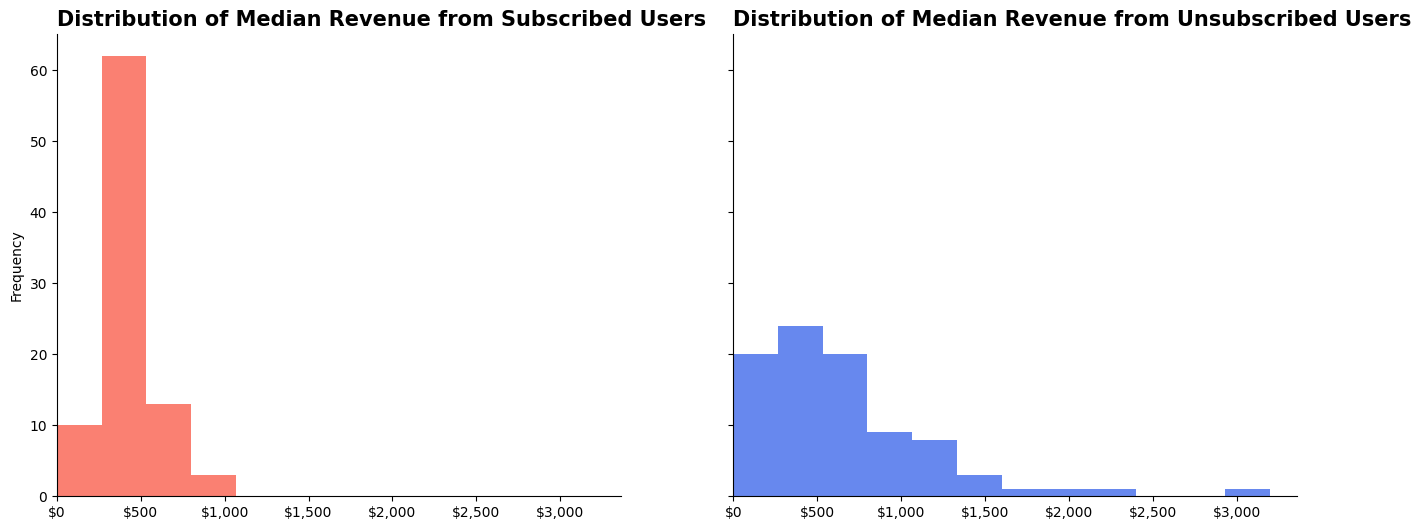

In [ ]:

fig, axs = plt.subplots( 1, 2, sharey=True, figsize=(16,6))
params = dict(bins=12, range=(0, 3200))

axs[0].hist(sales_email_subscription_median[0], **params, color = 'salmon')
axs[0].set_xlim(left=0)
axs[0].set_title('Distribution of Median Revenue from Subscribed Users',
          fontsize = 15,
          fontweight = 'bold',
                 loc='left')


axs[0].set_ylabel('')
axs[0].set_xlabel('')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[0].xaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )
axs[0].set_ylabel('Frequency')


axs[1].hist(sales_email_subscription_median[1], **params)
axs[1].set_title('Distribution of Median Revenue from Unsubscribed Users',
          fontsize = 15,
          fontweight = 'bold',
                 loc='left')



axs[1].set_xlabel('')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].set_xlim(0)


axs[1].xaxis.set_major_formatter(
        mtick.StrMethodFormatter('${x:,.0f}')
    )


In [ ]:
# Non parametric test to determine statistical significance

stat_median_unsubscr, p_value_mannwhitneyu_median_unsubscr = mannwhitneyu(sales_email_subscription_median[0].dropna(), sales_email_subscription_median[1].dropna())

print(f"U-statistic: {stat_median_unsubscr}")
print(f"P-value: {p_value_mannwhitneyu_median_unsubscr}")

# Interpretation
if p_value_mannwhitneyu_median_unsubscr < 0.05:
    print("There is a significant difference in median sales from subscribed and unsubscribed users.")
else:
    print("There is no significant difference in median sales from subscribed and unsubscribed users.")

U-statistic: 3039.5
P-value: 0.013805902703802459
There is a significant difference in median sales from subscribed and unsubscribed users.


The Mann–Whitney U test indicates a statistically significant difference in median revenue between subscribed and unsubscribed users.

### Across channels

In [ ]:
df['channel'].unique()

array(['Paid Search', 'Organic Search', 'Direct', 'Undefined',
       'Social Search'], dtype=object)

In [ ]:
sessions_by_channel = pd.pivot_table(df, index='date', columns='channel', values='ga_session_id', aggfunc='count')

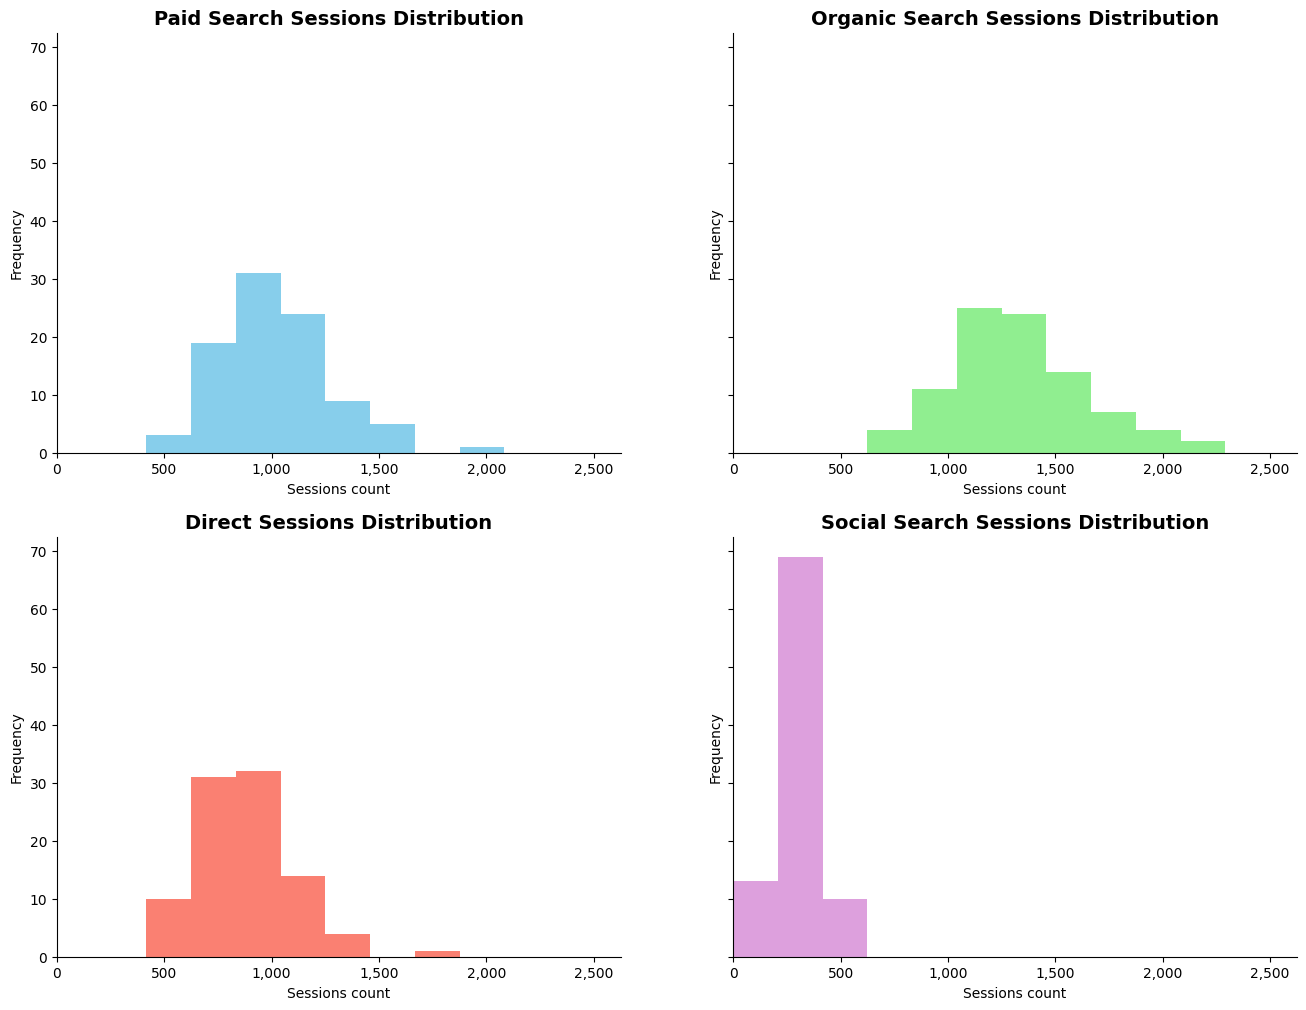

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, sharey=True, figsize=(16,12))
axs = axs.flatten()

params = dict(bins=12, range=(0, 2500))
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

channels = ['Paid Search', 'Organic Search', 'Direct', 'Social Search']

for ax, channel, color in zip(axs, channels, colors):
    ax.hist(sessions_by_channel[channel], color=color, **params)
    ax.set_xlim(left=0)
    ax.set_title(f'{channel} Sessions Distribution',
                 fontsize=14,
                 fontweight='bold')
    ax.set_xlabel('Sessions count')
    ax.set_ylabel('Frequency')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(
        mtick.StrMethodFormatter('{x:,.0f}')
    )

plt.show()


In [ ]:

stat_kruskal, p_value_kruskal = kruskal(sessions_by_channel['Organic Search'], sessions_by_channel['Paid Search'], sessions_by_channel['Social Search'], sessions_by_channel['Direct'])

print(f"Kruskal-Wallis statistic: {stat_kruskal}")
print(f"P-value: {p_value_kruskal}")

# Interpretation
if p_value < 0.05:
    print("There is a significant difference in numbers of sessions by channel.")
else:
    print("There is no significant difference in numbers of sessions by channel.")



Kruskal-Wallis statistic: 260.481538647879
P-value: 3.5370311010399424e-56
There is a significant difference in numbers of sessions by channel.


In [ ]:
print(f'Median Sessions Count, Paid Search: {sessions_by_channel['Paid Search'].median()}')
print(f'Median Sessions Count, Oragnic Search: {sessions_by_channel['Organic Search'].median()}')
print(f'Median Sessions Count, Social Search: {sessions_by_channel['Social Search'].median()}')
print(f'Median Sessions Count, Direct: {sessions_by_channel['Direct'].median()}')

Median Sessions Count, Paid Search: 989.0
Median Sessions Count, Oragnic Search: 1329.0
Median Sessions Count, Social Search: 308.0
Median Sessions Count, Direct: 869.5


The Kruskal Wallis Test indicates that there is a significant difference in traffic through different channels.
There are visible differences in central tendency and spread between channels.
It is clear, that Organic Search dominates in traffic volume, while Social Search contributes the least.
